# EDIS 8100 · Week 4 · Mini Project 1

## Build a teacher dashboard, then take it apart

**Estimated time: 20 minutes launched in class, about 2 hours to finish**

Fall 2026 · Dr. Hakeoung Hannah Lee · University of Virginia

---

Three panels, built with the same data you already know, for a teacher who has 150 minutes a week and 120 students. Then the harder half of the assignment: decide what each panel would actually cause a teacher to do, and where it would send them wrong.

You are not discovering the data this week. You already know two things about it:

- From **week 2**: how much a student clicks tells you surprisingly little about what they scored, and a visible group of students posts low click counts alongside high scores.
- From **week 3**: an at-risk model built on activity volume over-flagged first generation students who work long hours and study in bursts, and swapping the feature set fixed most of that gap.

Those two findings are your design constraints now, not your findings. The question this week is what you build knowing them.

## 🎯 What you will be able to do

By the end of this notebook you will be able to:

1. **Build** a three-panel teacher-facing dashboard in plotly from LMS, gradebook, and roster data, with a static snapshot of each panel for readers who cannot run the code.
2. **Attach a reason to every automated flag**, decomposing a model's risk score into the per-feature contributions that produced it.
3. **Evaluate** each panel against the decision a teacher would actually make from it, using van Leeuwen, Teasley, and Wise (2022) and Wise and Jung (2019).
4. **Argue in writing**, in a 300-word design memo, for one specific design change and say who it protects.

## How this notebook works

- **Run the cells in order, top to bottom.** Press `Shift+Enter`, or click the play button at the left of a cell.
- **Nothing here can break your computer,** and nothing here touches a real student. The roster is invented.
- **If something looks broken, start over from the top.** In Colab: `Runtime > Restart and run all`. In Jupyter: `Kernel > Restart & Run All`. That fixes nearly everything.
- **You do not have to write code to finish the core path.** Every cell marked ✏️ **Your turn** already contains a working answer, so the notebook runs start to finish untouched. Change those cells when you are ready, then re-run just that cell.
- **Two kinds of charts appear.** The plotly charts are interactive: hover a point to read a name, drag to zoom, double click to reset. Right after each one, a plain matplotlib snapshot of the same panel is drawn, because plotly charts do not show up when a notebook is read on GitHub. The snapshot is what your reader sees if they never open Colab.

If you have never written a line of code: you are exactly who this notebook was built for. The code is already written. The part that is genuinely hard here, deciding what a teacher should be shown and what they should be spared, needs your judgment about teaching, not your syntax.

## 📋 What you turn in for Mini Project 1

| Piece | Where it lives |
|---|---|
| The completed notebook, run top to bottom | Canvas, as a `.ipynb` file |
| A 300-word design memo | The clearly marked markdown cell in Part F of this notebook |
| Your AI interaction log plus a short reflection | Canvas, "AI Reflection" submission |

Due this week via Canvas. The full checklist is at the end of the notebook.

## ⚙️ Setup: run the next cell first

The cell below builds this week's three synthetic datasets (`students.csv`, `lms_clickstream.csv`, `gradebook.csv`) inside this runtime. Nothing to download, nothing to install, nothing to log into.

The data are synthetic on purpose. A dashboard is a surveillance instrument if you point it at people who never agreed to be watched, and a class assignment is a poor reason to open anyone's real record. So we invented a course instead, and the ask in return is simple: **treat this roster as if it were real.**

In [1]:
# ---------------------------------------------------------------------------
# This cell is long, and it is meant to be collapsed and ignored.
# It is here only so that the notebook works with no downloads and no accounts:
# it writes this week's synthetic CSVs into ./data/ inside your runtime.
# Click the arrow at the left edge to collapse it, run it once, and move on.
# ---------------------------------------------------------------------------

"""EDIS 8100 data generation, the subset needed for week04.
Extracted verbatim from data/generate_all_data.py so the numbers match the
canonical course datasets exactly. Seeds and helper functions are unchanged.
"""
from __future__ import annotations
import argparse
import time
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 8100
SEED_STUDENTS = SEED + 0
SEED_CLICKSTREAM = SEED + 1
SEED_GRADEBOOK = SEED + 2
DEFAULT_OUTDIR = Path('data')
N_STUDENTS = 120
N_GROUPS = 24
N_WEEKS = 8
COURSE_START = np.datetime64("2026-09-07T00:00:00")
DAY_S = 86400
QUIZ_DEADLINE_DAY = {k: 7 * k + 1 for k in range(1, N_WEEKS + 1)}
FINAL_PROJECT_DEADLINE_DAY = 64  # Tuesday 2026-11-10
STUDENT_COLS = [
    "student_id",
    "first_name",
    "last_name",
    "gender",
    "first_gen",
    "multilingual",
    "work_hours_per_week",
    "prior_gpa",
    "major_area",
]
def _outpath(outdir, filename: str) -> Path:
    path = Path(outdir).expanduser().resolve()
    path.mkdir(parents=True, exist_ok=True)
    return path / filename
def _ts(seconds_from_start) -> np.ndarray:
    """Seconds since COURSE_START to datetime64[s]."""
    secs = np.asarray(seconds_from_start, dtype="float64")
    return COURSE_START + np.round(secs).astype("int64").astype("timedelta64[s]")
def _iso(dt64) -> pd.Series:
    """Format datetime64 values as ISO 8601 strings without fractional seconds."""
    return pd.Series(pd.to_datetime(np.asarray(dt64))).dt.strftime("%Y-%m-%dT%H:%M:%S")
def _z(x) -> np.ndarray:
    x = np.asarray(x, dtype="float64")
    sd = x.std()
    return (x - x.mean()) / (sd if sd > 0 else 1.0)
def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype="float64")))
def _correlated(rng, base: np.ndarray, r: float) -> np.ndarray:
    """A standard normal vector correlated with `base` at approximately r."""
    noise = rng.normal(0, 1, base.size)
    return r * base + np.sqrt(max(0.0, 1.0 - r * r)) * noise
FIRST_NAMES_WOMAN = [
    "Aaliyah", "Sofia", "Mei", "Priya", "Emma", "Zara", "Isabella", "Hana",
    "Grace", "Amara", "Leila", "Camila", "Nia", "Yuki", "Ruth", "Elena",
    "Tanvi", "Noor", "Bridget", "Maya", "Ines", "Anika", "Kaia", "Rosa",
    "Delphine", "Simone", "Adaeze", "Lucia", "Hafsa", "Marta", "Thandiwe",
    "Colette", "Fatima", "Beatriz", "Solveig", "Imani",
]
FIRST_NAMES_MAN = [
    "Elijah", "Diego", "Ravi", "Omar", "Noah", "Tobias", "Malik", "Kenji",
    "Andre", "Samuel", "Hugo", "Nikhil", "Ivan", "Caleb", "Mateo", "Youssef",
    "Liam", "Dmitri", "Jonas", "Tariq", "Peter", "Wen", "Ezra", "Rafael",
    "Bilal", "Soren", "Kwame", "Julian", "Arun", "Felix", "Mikael", "Hector",
    "Devon", "Idris", "Lorenzo", "Emeka",
]
FIRST_NAMES_NONBINARY = [
    "Avery", "Rowan", "Quinn", "Sasha", "Jules", "Kai", "Ari", "Reese",
    "Emery", "Noel", "Marlowe", "Sage",
]
LAST_NAMES = [
    "Alvarez", "Nakamura", "Okoro", "Bennett", "Silva", "Petrov", "Haddad",
    "Nguyen", "Kowalski", "O'Neill", "Rahman", "Fitzgerald", "Mbeki", "Larsen",
    "Duarte", "Chowdhury", "Vasquez", "Kim", "Delgado", "Whitfield", "Osei",
    "Ramirez", "Baptiste", "Lindqvist", "Serrano", "Tran", "Abebe", "Moreau",
    "Castillo", "Yamada", "Hollis", "Bright", "Novak", "Iyer", "Sandoval",
    "Keller", "Adeyemi", "Marchetti", "Villanueva", "Sokolov", "Barros",
    "Ferreira", "Nwosu", "Hassan", "Blackwell", "Mendoza", "Park", "Rossi",
    "Grant", "Solano", "Achebe", "Bauer", "Cruz", "Dawson", "Egan", "Farrell",
]
MAJOR_AREAS = [
    "education", "psychology", "data science", "nursing", "engineering", "humanities",
]
MAJOR_PROBS = [0.30, 0.22, 0.12, 0.15, 0.09, 0.12]
def make_students(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Build the 120 students of EDUC 1010 and their latent traits.

    Writes students.csv (the nine documented columns only). The returned frame
    also carries the latent traits that every other generator needs. Latents are
    never written to disk: students in the course are supposed to discover the
    planted structure, not read it off a column.
    """
    rng = np.random.default_rng(SEED_STUDENTS)
    n = N_STUDENTS

    student_id = np.array([f"S{i + 1:03d}" for i in range(n)])

    # Core latent traits.
    ability = rng.normal(0, 1, n)                       # what the assessments track
    engagement = _correlated(rng, ability, 0.20)        # how much they click
    srl_skill = _correlated(rng, ability, 0.35)         # planning, monitoring, reflecting
    procrastination = -0.42 * srl_skill + np.sqrt(1 - 0.42**2) * rng.normal(0, 1, n)
    # Regularity is how many separate days a student touches the course. It helps
    # learning, and it is also the feature the naive at-risk model leans on.
    regularity = 0.35 * engagement + 0.30 * srl_skill + 0.85 * rng.normal(0, 1, n)
    talkativeness = rng.normal(0, 1, n)                 # studio floor time
    chat_propensity = 0.30 * talkativeness + 0.95 * rng.normal(0, 1, n)
    doc_propensity = rng.normal(0, 1, n)
    forum_propensity = 0.30 * engagement + np.sqrt(1 - 0.30**2) * rng.normal(0, 1, n)

    # Demographics.
    gender = rng.choice(["woman", "man", "nonbinary"], size=n, p=[0.61, 0.34, 0.05])
    first_gen = (rng.random(n) < 0.30).astype(int)
    multilingual = (rng.random(n) < 0.24).astype(int)
    major_area = rng.choice(MAJOR_AREAS, size=n, p=MAJOR_PROBS)

    prior_gpa = np.clip(3.16 + 0.42 * ability + rng.normal(0, 0.17, n), 2.0, 4.0)
    prior_gpa = np.round(prior_gpa, 2)

    # Paid work. First generation students in this cohort work more hours, which
    # is what makes the naive at-risk model in week 3 go wrong.
    work_raw = rng.gamma(1.9, 4.3, n) + first_gen * rng.uniform(5.0, 14.0, n)
    work_hours = np.clip(np.round(work_raw), 0, 30).astype(int)

    # P2 group: works 15+ hours, first generation, studies in concentrated bursts.
    burst_worker = ((first_gen == 1) & (work_hours >= 15)).astype(int)

    # P1 group: high ability, low clickstream volume. The "efficient" cluster.
    efficient = np.zeros(n, dtype=int)
    eligible = np.where((ability > 0.28) & (burst_worker == 0))[0]
    efficient[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # P6 group: requests hints in rapid bursts instead of working the problem.
    hint_spam = np.zeros(n, dtype=int)
    eligible = np.where(srl_skill < 0.15)[0]
    hint_spam[rng.choice(eligible, size=min(18, eligible.size), replace=False)] = 1

    # Forum structure for P4: three loose clusters plus four bridge builders.
    community = np.tile(np.arange(3), int(np.ceil(n / 3)))[:n]
    rng.shuffle(community)

    silent_forum = (forum_propensity < np.quantile(forum_propensity, 0.18)).astype(int)

    fp_rank = forum_propensity.argsort().argsort() / (n - 1)
    connector = np.zeros(n, dtype=int)
    conn_pool = np.where((fp_rank > 0.45) & (fp_rank < 0.74) & (silent_forum == 0))[0]
    chosen = []
    for comm in [0, 1, 2]:
        opts = [i for i in conn_pool if community[i] == comm]
        if opts:
            chosen.append(int(rng.choice(opts)))
    remaining = [i for i in conn_pool if i not in chosen]
    while len(chosen) < 4 and remaining:
        pick = int(rng.choice(remaining))
        chosen.append(pick)
        remaining.remove(pick)
    connector[np.array(chosen, dtype=int)] = 1

    # Studio groups of five. Multilingual students are dealt round robin so that
    # no group ends up as an artifact of the assignment procedure.
    order = np.lexsort((rng.random(n), -multilingual))
    group_index = np.empty(n, dtype=int)
    group_index[order] = np.arange(n) % N_GROUPS
    group_id = np.array([f"G{g + 1:02d}" for g in group_index])

    # Names. Keep full names unique so student_id is never ambiguous in class.
    first_name = np.empty(n, dtype=object)
    last_name = np.empty(n, dtype=object)
    used = set()
    for i in range(n):
        if gender[i] == "woman":
            bank = FIRST_NAMES_WOMAN
        elif gender[i] == "man":
            bank = FIRST_NAMES_MAN
        else:
            bank = FIRST_NAMES_NONBINARY
        for _ in range(400):
            fn = str(rng.choice(bank))
            ln = str(rng.choice(LAST_NAMES))
            if (fn, ln) not in used:
                break
        used.add((fn, ln))
        first_name[i] = fn
        last_name[i] = ln

    df = pd.DataFrame(
        {
            "student_id": student_id,
            "first_name": first_name,
            "last_name": last_name,
            "gender": gender,
            "first_gen": first_gen,
            "multilingual": multilingual,
            "work_hours_per_week": work_hours,
            "prior_gpa": prior_gpa,
            "major_area": major_area,
            # latent traits below this line, never written to CSV
            "ability": ability,
            "engagement": engagement,
            "srl_skill": srl_skill,
            "procrastination": procrastination,
            "regularity": regularity,
            "talkativeness": talkativeness,
            "chat_propensity": chat_propensity,
            "doc_propensity": doc_propensity,
            "forum_propensity": forum_propensity,
            "efficient": efficient,
            "burst_worker": burst_worker,
            "hint_spam": hint_spam,
            "community": community,
            "connector": connector,
            "silent_forum": silent_forum,
            "group_id": group_id,
        }
    )

    if write:
        df[STUDENT_COLS].to_csv(_outpath(outdir, "students.csv"), index=False)
    return df
EVENT_TYPES = [
    "login", "page_view", "video_play", "video_pause",
    "forum_view", "assignment_view", "submit",
]
EVENT_BASE_P = np.array([0.12, 0.32, 0.16, 0.11, 0.13, 0.11, 0.05])
def make_clickstream(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """LMS event log for the eight course weeks.

    Two things vary across students and they are not the same thing. Volume is how
    many events a student generates, and it is heavy tailed. Regularity is how many
    separate days they show up at all. The week also has a rhythm: Monday and
    Tuesday spike ahead of the Tuesday night quiz deadline.

    Two subgroups break the "more clicks means more learning" story. Efficient
    students generate few events and score well (P1). First generation students
    working 15+ hours can only touch the course on a handful of days, so their
    regularity looks terrible even though their learning does not (P2).
    """
    rng = np.random.default_rng(SEED_CLICKSTREAM)
    students = make_students(write=False)
    n = len(students)

    ability = students["ability"].to_numpy()
    engagement = students["engagement"].to_numpy()
    procrast = students["procrastination"].to_numpy()
    regularity_z = _z(students["regularity"].to_numpy())
    efficient = students["efficient"].to_numpy()
    burst = students["burst_worker"].to_numpy()

    # Expected event count per student, lognormal so the tail is heavy.
    log_mu = (
        5.78
        + 0.40 * engagement
        + 0.05 * ability
        + 0.10 * regularity_z
        + np.log(np.where(efficient == 1, 0.30, 1.0))
        + np.log(np.where(burst == 1, 0.95, 1.0))
    )
    n_events = np.clip(
        np.round(np.exp(log_mu + rng.normal(0, 0.18, n))), 25, 4000
    ).astype(int)

    n_days = N_WEEKS * 7
    day_index = np.arange(n_days)
    weekday = (day_index + 0) % 7  # 0 = Monday, because 2026-09-07 is a Monday
    weekday_weight = np.array([1.45, 1.60, 1.10, 1.00, 0.75, 0.60, 1.05])
    weekday_rel = weekday_weight / weekday_weight.mean()
    week_of = day_index // 7
    week_weight = 1.0 - 0.022 * week_of  # attention fades a little across the term
    base_day_w = weekday_weight[weekday] * week_weight

    # Probability that a given student touches the course on a given day.
    p_active = _sigmoid(0.45 + 0.95 * regularity_z)
    # Working 15+ hours compresses the week into a couple of long evenings.
    p_active = np.where(burst == 1, p_active * 0.18, p_active)

    # Submit events crowd into the 48 hours before each Tuesday deadline.
    submit_day_w = np.where(np.isin(weekday, [0, 1]), 5.0, 0.70) * week_weight

    rows_student, rows_day, rows_type = [], [], []
    rows_hour = []

    for i in range(n):
        k = int(n_events[i])
        day_p = np.clip(p_active[i] * weekday_rel[weekday] * week_weight, 0.01, 0.97)
        active = rng.random(n_days) < day_p
        if active.sum() < 4:
            active[rng.choice(n_days, size=4, replace=False)] = True

        w = base_day_w * active * (0.55 + rng.gamma(3.0, 1.0 / 3.0, n_days))
        w = w / w.sum()
        sw = submit_day_w * active
        sw = sw / sw.sum()

        # Per-student taste for videos versus pages versus the forum.
        p_types = rng.dirichlet(EVENT_BASE_P * 55.0)
        types = rng.choice(len(EVENT_TYPES), size=k, p=p_types)

        days = rng.choice(n_days, size=k, p=w)
        is_submit = types == EVENT_TYPES.index("submit")
        if is_submit.any():
            days[is_submit] = rng.choice(n_days, size=int(is_submit.sum()), p=sw)

        # Time of day: three loose study sessions, later for procrastinators.
        centers = rng.choice(
            [9.6, 14.2, 20.8], size=k, p=[0.27, 0.33, 0.40]
        ) + 1.05 * procrast[i] * rng.random(k)
        hours = centers + rng.normal(0, 0.85, k)
        hours = np.clip(hours, 0.02, 23.97)

        rows_student.append(np.full(k, i))
        rows_day.append(days)
        rows_type.append(types)
        rows_hour.append(hours)

    student_idx = np.concatenate(rows_student)
    days = np.concatenate(rows_day)
    types = np.concatenate(rows_type)
    hours = np.concatenate(rows_hour)

    seconds = days * DAY_S + hours * 3600.0
    order = np.argsort(seconds, kind="stable")
    student_idx, days, types, seconds = (
        student_idx[order], days[order], types[order], seconds[order]
    )

    week = (days // 7 + 1).astype(int)
    type_names = np.array(EVENT_TYPES)[types]

    # Plausible resource ids per event type.
    resource = np.empty(seconds.size, dtype=object)
    page_no = rng.integers(1, 9, seconds.size)
    video_no = rng.integers(1, 5, seconds.size)
    thread_no = rng.integers(1, 61, seconds.size)
    for t, name in enumerate(EVENT_TYPES):
        mask = types == t
        if not mask.any():
            continue
        if name == "login":
            resource[mask] = "lms_home"
        elif name == "page_view":
            resource[mask] = [
                f"w{w}_page_{p:02d}" for w, p in zip(week[mask], page_no[mask])
            ]
        elif name in ("video_play", "video_pause"):
            resource[mask] = [
                f"w{w}_video_{v:02d}" for w, v in zip(week[mask], video_no[mask])
            ]
        elif name == "forum_view":
            resource[mask] = [f"thread_{t3:03d}" for t3 in thread_no[mask]]
        else:  # assignment_view and submit both point at the next quiz due
            deadline_days = np.array([QUIZ_DEADLINE_DAY[k] for k in range(1, N_WEEKS + 1)])
            next_quiz = np.clip(
                1 + np.searchsorted(deadline_days, days[mask], side="left"), 1, N_WEEKS
            )
            resource[mask] = [f"quiz_{k}" for k in next_quiz]

    df = pd.DataFrame(
        {
            "event_id": [f"E{i + 1:06d}" for i in range(seconds.size)],
            "student_id": students["student_id"].to_numpy()[student_idx],
            "timestamp": _iso(_ts(seconds)),
            "week": week,
            "event_type": type_names,
            "resource_id": resource,
        }
    )
    if write:
        df.to_csv(_outpath(outdir, "lms_clickstream.csv"), index=False)
    return df
QUIZ_DIFFICULTY = np.array([2.2, 0.4, -3.1, -0.8, 1.1, -2.4, 0.2, 1.4])
def make_gradebook(outdir=DEFAULT_OUTDIR, write: bool = True) -> pd.DataFrame:
    """Eight quizzes plus a final project, with submission and deadline stamps.

    Two planted structures live here. Quiz to quiz improvement tracks self
    regulated learning skill and is flattest for the hint spam subgroup (P6,
    completed by srl_traces.csv). Submission timing tracks procrastination, which
    also drags scores down, so last minute submissions score lower (P3). The link
    is correlational by construction: nothing about submitting late causes the
    lower score, which is exactly the inference students should have to argue about.
    """
    rng = np.random.default_rng(SEED_GRADEBOOK)
    students = make_students(write=False)
    n = len(students)

    ability = students["ability"].to_numpy()
    engagement = students["engagement"].to_numpy()
    srl = students["srl_skill"].to_numpy()
    procrast = students["procrastination"].to_numpy()
    hint_spam = students["hint_spam"].to_numpy()
    burst = students["burst_worker"].to_numpy()
    sid = students["student_id"].to_numpy()

    srl_z = _z(srl)
    procrast_z = _z(procrast)
    regularity_z = _z(students["regularity"].to_numpy())

    base = (
        76.0
        + 7.2 * ability
        + 1.9 * srl_z
        + 0.3 * engagement
        + 4.2 * regularity_z
        - 4.1 * procrast_z
        - 0.6 * burst
        + rng.normal(0, 2.0, n)
    )
    # Growth across the term: SRL loops pay off, hint spamming does not.
    slope = 0.68 * srl_z - 0.62 * hint_spam + 0.12 * ability + rng.normal(0, 0.35, n)

    rows = []
    for k in range(1, N_WEEKS + 1):
        raw = (
            base
            + slope * (k - 4.5)
            + QUIZ_DIFFICULTY[k - 1]
            + rng.normal(0, 6.0, n)
        )
        score = np.round(np.clip(raw, 32.0, 100.0), 1)

        deadline_s = QUIZ_DEADLINE_DAY[k] * DAY_S + 23 * 3600 + 59 * 60
        # Hours before the deadline: procrastinators cut it close.
        mu = 3.25 - 1.35 * procrast_z
        hours_before = np.exp(mu + rng.normal(0, 0.85, n))
        # A quiz cannot be submitted before it exists. It opens with its own
        # week, so the earliest possible submission is that week's first moment.
        # Saturating against that window leaves the last minute tail exactly as
        # drawn (1 - exp(-x) is x for small x) and only bends the early tail, so
        # nobody stacks up on the release instant.
        open_s = (k - 1) * 7 * DAY_S
        max_hours = (deadline_s - open_s) / 3600.0
        hours_before = max_hours * (1.0 - np.exp(-hours_before / max_hours))
        hours_before = np.clip(hours_before, 0.03, max_hours)
        # A few submissions land after the bell.
        late = rng.random(n) < (0.02 + 0.035 * _sigmoid(1.4 * procrast_z))
        hours_before = np.where(late, -rng.uniform(0.2, 11.0, n), hours_before)
        submit_s = deadline_s - hours_before * 3600.0

        rows.append(
            pd.DataFrame(
                {
                    "student_id": sid,
                    "assessment": f"quiz_{k}",
                    "score": score,
                    "submitted_at": _iso(_ts(submit_s)),
                    "deadline": _iso(_ts(np.full(n, deadline_s))),
                }
            )
        )

    quizzes = pd.concat(rows, ignore_index=True)

    mean_quiz = quizzes.groupby("student_id")["score"].mean().reindex(sid).to_numpy()
    fp_raw = 0.55 * mean_quiz + 0.45 * (77.0 + 7.0 * ability + 2.0 * srl_z) + rng.normal(0, 4.6, n)
    fp_score = np.round(np.clip(fp_raw, 40.0, 100.0), 1)
    fp_deadline_s = FINAL_PROJECT_DEADLINE_DAY * DAY_S + 23 * 3600 + 59 * 60
    fp_hours = np.clip(np.exp(3.05 - 1.2 * procrast_z + rng.normal(0, 0.8, n)), 0.05, 14 * 24)
    final_project = pd.DataFrame(
        {
            "student_id": sid,
            "assessment": "final_project",
            "score": fp_score,
            "submitted_at": _iso(_ts(fp_deadline_s - fp_hours * 3600.0)),
            "deadline": _iso(_ts(np.full(n, fp_deadline_s))),
        }
    )

    df = pd.concat([quizzes, final_project], ignore_index=True)
    df = df.sort_values(["student_id", "assessment"], kind="stable").reset_index(drop=True)
    if write:
        df.to_csv(_outpath(outdir, "gradebook.csv"), index=False)
    return df


def build_data(outdir='data'):
    import os
    os.makedirs(outdir, exist_ok=True)
    make_students(outdir=outdir)
    make_clickstream(outdir=outdir)
    make_gradebook(outdir=outdir)
    return outdir


build_data(outdir='data')
print('Data ready. Files created in ./data:')
import os
for f in sorted(os.listdir('data')): print('  ', f)

Data ready. Files created in ./data:
   gradebook.csv
   lms_clickstream.csv
   students.csv


## 📊 Part A. Orientation: what is actually in front of you

Before anyone draws a chart, the useful question is what the files can and cannot say. A dashboard inherits every limit of the data underneath it, and then hides those limits behind a nice layout. That is the single most common way a dashboard misleads: not by being wrong, but by looking complete.

The next cell does three things:

1. Loads the three files and reports what one row means in each.
2. Collapses the clickstream to **one row per student**, which is the shape almost every dashboard panel needs.
3. Prints the calendar boundaries, because those matter more than they look.

Watch the last block of the printout in particular.

In [2]:
%matplotlib inline
# the line above just tells the notebook to draw matplotlib charts here on the page

import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

# Plotly has to know where it is drawing. Inside Colab it uses Colab's own renderer;
# anywhere else (local Jupyter, nbconvert) it uses the standard notebook renderer.
pio.renderers.default = "colab" if "google.colab" in sys.modules else "notebook_connected"

pd.set_option("display.width", 130)

# A colorblind-safe palette (Okabe and Ito). Nothing in this notebook asks you to
# tell red from green, and every colour distinction is backed up by a shape or a label.
BLUE, ORANGE, SKY, PURPLE, GREY, VERM = (
    "#0072b2", "#e69f00", "#56b4e9", "#cc79a7", "#7f7f7f", "#d55e00")

students = pd.read_csv("data/students.csv")
clicks   = pd.read_csv("data/lms_clickstream.csv", parse_dates=["timestamp"])
grades   = pd.read_csv("data/gradebook.csv", parse_dates=["submitted_at", "deadline"])

print("WHAT ONE ROW MEANS IN EACH FILE")
print(f"  students.csv ......... one student            {len(students):>6,} rows")
print(f"  lms_clickstream.csv .. one click in the LMS   {len(clicks):>6,} rows")
print(f"  gradebook.csv ........ one student, one test  {len(grades):>6,} rows")

# ---- collapse the clickstream to one row per student ----------------------
clicks["day"] = clicks["timestamp"].dt.date

volume = clicks.groupby("student_id").agg(
    total_events=("event_id", "count"),   # how MUCH the student clicked
    active_days=("day", "nunique"),       # on how many separate days they showed up
)
by_type = (clicks.pivot_table(index="student_id", columns="event_type",
                              values="event_id", aggfunc="count")
           .fillna(0).astype(int))
by_type.columns.name = None
activity = volume.join(by_type)

# ---- the outcome the dashboard cares about --------------------------------
quizzes = grades[grades["assessment"].str.startswith("quiz_")].copy()
mean_quiz = quizzes.groupby("student_id")["score"].mean().rename("mean_quiz")

# ---- one row per student: this table feeds every panel --------------------
dash = (students.set_index("student_id").join(activity).join(mean_quiz).reset_index())

RISK_CUTOFF = 70          # a mean quiz score below this counts as "at risk"
dash["at_risk"] = (dash["mean_quiz"] < RISK_CUTOFF).astype(int)

print(f"\nDASHBOARD TABLE: {dash.shape[0]} students by {dash.shape[1]} columns")
print(f"  students whose mean quiz score is below {RISK_CUTOFF}: "
      f"{dash['at_risk'].sum()} ({dash['at_risk'].mean():.0%} of the class)")

# ---- the calendar, which is where the quiet problems live -----------------
deadlines = quizzes.groupby("assessment")["deadline"].first().sort_values()
final_deadline = grades.loc[grades["assessment"] == "final_project", "deadline"].iloc[0]
export_end = clicks["timestamp"].max()

print("\nCALENDAR BOUNDARIES (read this part twice)")
print(f"  clickstream export runs .... {clicks['timestamp'].min():%Y-%m-%d} to {export_end:%Y-%m-%d}")
print(f"  quiz_8 is due .............. {deadlines['quiz_8']:%Y-%m-%d}   "
      f"({(deadlines['quiz_8'] - export_end).days} days AFTER the export ends)")
print(f"  final project is due ....... {final_deadline:%Y-%m-%d}   "
      f"({(final_deadline - export_end).days} days AFTER the export ends)")
print("  So for the two assessments that matter most, this dashboard has no behaviour data at all.")

dash[["student_id", "first_name", "last_name", "first_gen", "work_hours_per_week",
      "prior_gpa", "total_events", "active_days", "submit", "mean_quiz"]].head(6)

WHAT ONE ROW MEANS IN EACH FILE
  students.csv ......... one student               120 rows
  lms_clickstream.csv .. one click in the LMS   41,117 rows
  gradebook.csv ........ one student, one test   1,080 rows

DASHBOARD TABLE: 120 students by 20 columns
  students whose mean quiz score is below 70: 34 (28% of the class)

CALENDAR BOUNDARIES (read this part twice)
  clickstream export runs .... 2026-09-07 to 2026-11-01
  quiz_8 is due .............. 2026-11-03   (2 days AFTER the export ends)
  final project is due ....... 2026-11-10   (9 days AFTER the export ends)
  So for the two assessments that matter most, this dashboard has no behaviour data at all.


,student_id,first_name,last_name,first_gen,work_hours_per_week,prior_gpa,total_events,active_days,submit,mean_quiz
0,S001,Avery,Kim,1,23,3.38,338,7,11,81.4125
1,S002,Hana,Mbeki,1,16,3.38,341,4,29,69.8750
2,S003,Tanvi,Nakamura,1,29,3.03,218,7,4,73.3250
3,S004,Jonas,Lindqvist,0,9,2.92,591,29,40,74.1500
4,S005,Fatima,Grant,0,3,3.00,269,37,3,70.1875
5,S006,Fatima,Solano,1,13,3.63,157,32,8,92.1375


**Before you go on.** Two things in that printout are worth saying out loud to the person next to you.

First, `at_risk` is not a fact about a student. It is a line somebody drew at 70, and moving the line moves the number of students who are "at risk." Every dashboard you have ever used contains at least one of these lines, usually undocumented.

Second, the clickstream stops before the last quiz and long before the final project. A teacher looking at an activity panel in the last week of term is looking at a picture of the past that has already stopped updating. Nothing on the screen will say so.

### ✏️ Your turn 1: name the two questions

A dashboard is an answer to a question somebody chose. Before you build anything, write down one question these three files **could** genuinely inform, and one they **cannot touch** no matter how good your charts are.

The cell below already contains a working pair of answers so the notebook runs untouched. Replace them with your own. Keep them concrete: "does the student understand spacing" is not a question the files can answer, but neither is it specific enough to be interesting.

Your answers print into a design brief that you will want in front of you for Part E and the memo.

In [3]:
# ✏️ TODO: replace these two strings with your own questions.
#          The defaults below already work, so you can run this cell first and edit after.

QUESTION_THE_FILES_CAN_INFORM = (
    "Which students' quiz scores fell by more than 10 points between quiz 5 and quiz 8?"
)

QUESTION_THE_FILES_CANNOT_TOUCH = (
    "Why did those scores fall, and which of the supports this course offers would have helped?"
)


# --- a friendly safety net: blank answers fall back to the defaults ---------
_a = QUESTION_THE_FILES_CAN_INFORM.strip() or "Which students' quiz scores fell after quiz 5?"
_b = QUESTION_THE_FILES_CANNOT_TOUCH.strip() or "Why did those scores fall?"

def _wrap(text, width=74, indent="  "):
    words, line, out = text.split(), "", []
    for w in words:
        if len(line) + len(w) + 1 > width:
            out.append(indent + line); line = w
        else:
            line = f"{line} {w}".strip()
    out.append(indent + line)
    return "\n".join(out)

print("=" * 78)
print("  DESIGN BRIEF: MINI PROJECT 1")
print("=" * 78)
print("\n  A question these files CAN inform:\n")
print(_wrap(_a))
print("\n  A question these files CANNOT touch:\n")
print(_wrap(_b))
print("\n" + "=" * 78)
print("  Keep the second question visible while you build. Every panel below is")
print("  built from the first kind of question, and a teacher reading the screen")
print("  has no way to tell the difference.")
print("=" * 78)

  DESIGN BRIEF: MINI PROJECT 1

  A question these files CAN inform:

  Which students' quiz scores fell by more than 10 points between quiz 5 and
  quiz 8?

  A question these files CANNOT touch:

  Why did those scores fall, and which of the supports this course offers
  would have helped?

  Keep the second question visible while you build. Every panel below is
  built from the first kind of question, and a teacher reading the screen
  has no way to tell the difference.


## 📊 Part B. The class overview panel

This is the panel a teacher sees first, usually on a Monday morning, usually for about forty seconds. It has to answer "how is my class doing" fast enough to be read between meetings.

Four small charts, chosen deliberately:

1. **Where the scores sit.** A histogram of each student's mean quiz score, with the class median marked. Distribution, not average, because an average of 76 can hide almost anything.
2. **When the class works.** Total LMS events per day across the term, with the quiz deadlines marked. This is the rhythm of the course as students actually live it.
3. **Activity against achievement.** The scatterplot you met in week 2. Students in the bottom third of activity and the top quarter of scores are drawn as orange diamonds, because they are the ones this panel is most likely to get somebody in trouble over.
4. **The same data, aggregated.** The share of each activity third that fell below the cutoff. Panel 3 and panel 4 are built from identical numbers. Put them next to each other and watch what aggregation does to how sure you feel.

Hover any point in the interactive version to see who it is.

In [4]:
# ---- inputs for the four panels -------------------------------------------
daily_events = clicks.groupby(clicks["timestamp"].dt.normalize()).size()
deadline_days = pd.to_datetime(deadlines.dt.normalize().values)

# Only the deadlines that fall inside the export window can be marked on the line.
# The ones that fall outside it are exactly the problem, so we say so on the chart.
inside = deadline_days[deadline_days <= daily_events.index.max()]
outside = deadline_days[deadline_days > daily_events.index.max()]
events_on_deadline_days = daily_events.reindex(inside)
outside_note = (f"{len(outside)} later deadline(s) fall after the export ends"
                if len(outside) else "all deadlines fall inside the export window")

r_activity_score = dash["total_events"].corr(dash["mean_quiz"])

low_activity_cut = dash["total_events"].quantile(1 / 3)
high_score_cut = dash["mean_quiz"].quantile(0.75)
dash["efficient"] = ((dash["total_events"] <= low_activity_cut) &
                     (dash["mean_quiz"] >= high_score_cut))

slope, intercept = np.polyfit(dash["total_events"], dash["mean_quiz"], 1)
fit_x = np.linspace(dash["total_events"].min(), dash["total_events"].max(), 50)
fit_y = slope * fit_x + intercept

dash["activity_third"] = pd.qcut(dash["total_events"], 3,
                                 labels=["Lowest third", "Middle third", "Highest third"])
tercile = dash.groupby("activity_third", observed=True).agg(
    students=("student_id", "count"),
    median_events=("total_events", "median"),
    mean_score=("mean_quiz", "mean"),
    share_below_cutoff=("at_risk", "mean"),
).round(2)

usual = dash[~dash["efficient"]]
eff = dash[dash["efficient"]]
label = dash["first_name"] + " " + dash["last_name"] + " (" + dash["student_id"] + ")"

# ---- the interactive panel -------------------------------------------------
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "1. Where the scores sit: mean quiz score per student",
        "2. When the class works: LMS events per day",
        f"3. Activity against achievement (r = {r_activity_score:.2f})",
        "4. The same data, aggregated by thirds",
    ),
    vertical_spacing=0.16, horizontal_spacing=0.11,
)

# panel 1: distribution
fig.add_trace(go.Histogram(x=dash["mean_quiz"], xbins=dict(start=40, end=100, size=4),
                           marker_color=BLUE, name="Students",
                           hovertemplate="Mean quiz %{x}<br>%{y} students<extra></extra>"),
              row=1, col=1)
fig.add_vline(x=float(dash["mean_quiz"].median()), line_dash="dash", line_color=VERM,
              annotation_text=f"median {dash['mean_quiz'].median():.1f}",
              annotation_position="top right", row=1, col=1)

# panel 2: rhythm
fig.add_trace(go.Scatter(x=daily_events.index, y=daily_events.values, mode="lines",
                         line=dict(color=BLUE, width=2), name="Events per day",
                         hovertemplate="%{x|%a %d %b}<br>%{y:,} events<extra></extra>"),
              row=1, col=2)
fig.add_trace(go.Scatter(x=events_on_deadline_days.index, y=events_on_deadline_days.values,
                         mode="markers", marker=dict(color=ORANGE, size=11, symbol="diamond",
                                                     line=dict(color="white", width=1)),
                         name="Quiz deadline (Tue 23:59)",
                         hovertemplate="Quiz deadline %{x|%d %b}<br>%{y:,} events<extra></extra>"),
              row=1, col=2)
fig.add_annotation(text=outside_note, xref="x2 domain", yref="y2 domain",
                   x=0.98, y=0.02, showarrow=False, xanchor="right",
                   font=dict(size=11, color=VERM))

# panel 3: activity vs achievement
fig.add_trace(go.Scatter(x=usual["total_events"], y=usual["mean_quiz"], mode="markers",
                         marker=dict(color=BLUE, size=8, opacity=0.65),
                         name="Student",
                         customdata=label[~dash["efficient"]],
                         hovertemplate="%{customdata}<br>%{x:,} events<br>mean quiz %{y:.1f}<extra></extra>"),
              row=2, col=1)
fig.add_trace(go.Scatter(x=eff["total_events"], y=eff["mean_quiz"], mode="markers",
                         marker=dict(color=ORANGE, size=13, symbol="diamond",
                                     line=dict(color="black", width=1)),
                         name="Low activity, high score",
                         customdata=label[dash["efficient"]],
                         hovertemplate="%{customdata}<br>%{x:,} events<br>mean quiz %{y:.1f}<extra></extra>"),
              row=2, col=1)
fig.add_trace(go.Scatter(x=fit_x, y=fit_y, mode="lines", showlegend=False,
                         line=dict(color=GREY, dash="dot", width=2), hoverinfo="skip"),
              row=2, col=1)

# panel 4: the same data, aggregated
fig.add_trace(go.Bar(x=list(tercile.index), y=tercile["share_below_cutoff"], marker_color=SKY,
                     marker_line=dict(color="black", width=1),
                     name=f"Share below {RISK_CUTOFF}",
                     text=[f"{p:.0%}<br>mean {v:.1f}"
                           for p, v in zip(tercile["share_below_cutoff"], tercile["mean_score"])],
                     textposition="outside",
                     hovertemplate=("%{x}<br>%{y:.0%} below the cutoff<extra></extra>")),
              row=2, col=2)

fig.update_xaxes(title_text="Mean quiz score (0 to 100)", row=1, col=1)
fig.update_yaxes(title_text="Number of students", row=1, col=1)
fig.update_xaxes(title_text="Date", row=1, col=2)
fig.update_yaxes(title_text="LMS events that day", row=1, col=2)
fig.update_xaxes(title_text="Total LMS events over the term", row=2, col=1)
fig.update_yaxes(title_text="Mean quiz score", row=2, col=1)
fig.update_xaxes(title_text="Third of the class by total LMS events", row=2, col=2)
fig.update_yaxes(title_text=f"Share scoring below {RISK_CUTOFF}", range=[0, 0.55],
                 tickformat=".0%", row=2, col=2)

fig.update_layout(
    height=820, width=1050, template="simple_white", bargap=0.06,
    title=dict(text="EDUC 1010 · Class overview · weeks 1 to 8",
               x=0.5, font=dict(size=19)),
    legend=dict(orientation="h", yanchor="bottom", y=-0.13, xanchor="center", x=0.5),
)
fig.show()

The interactive panel above will not appear when this notebook is read on GitHub, because GitHub does not run javascript. The next cell draws the same four charts with matplotlib so that the committed file shows something real, and prints the summary table underneath.

A dashboard that only exists when the reader has the right software is a dashboard most of your colleagues will never see. This is a small habit worth keeping.

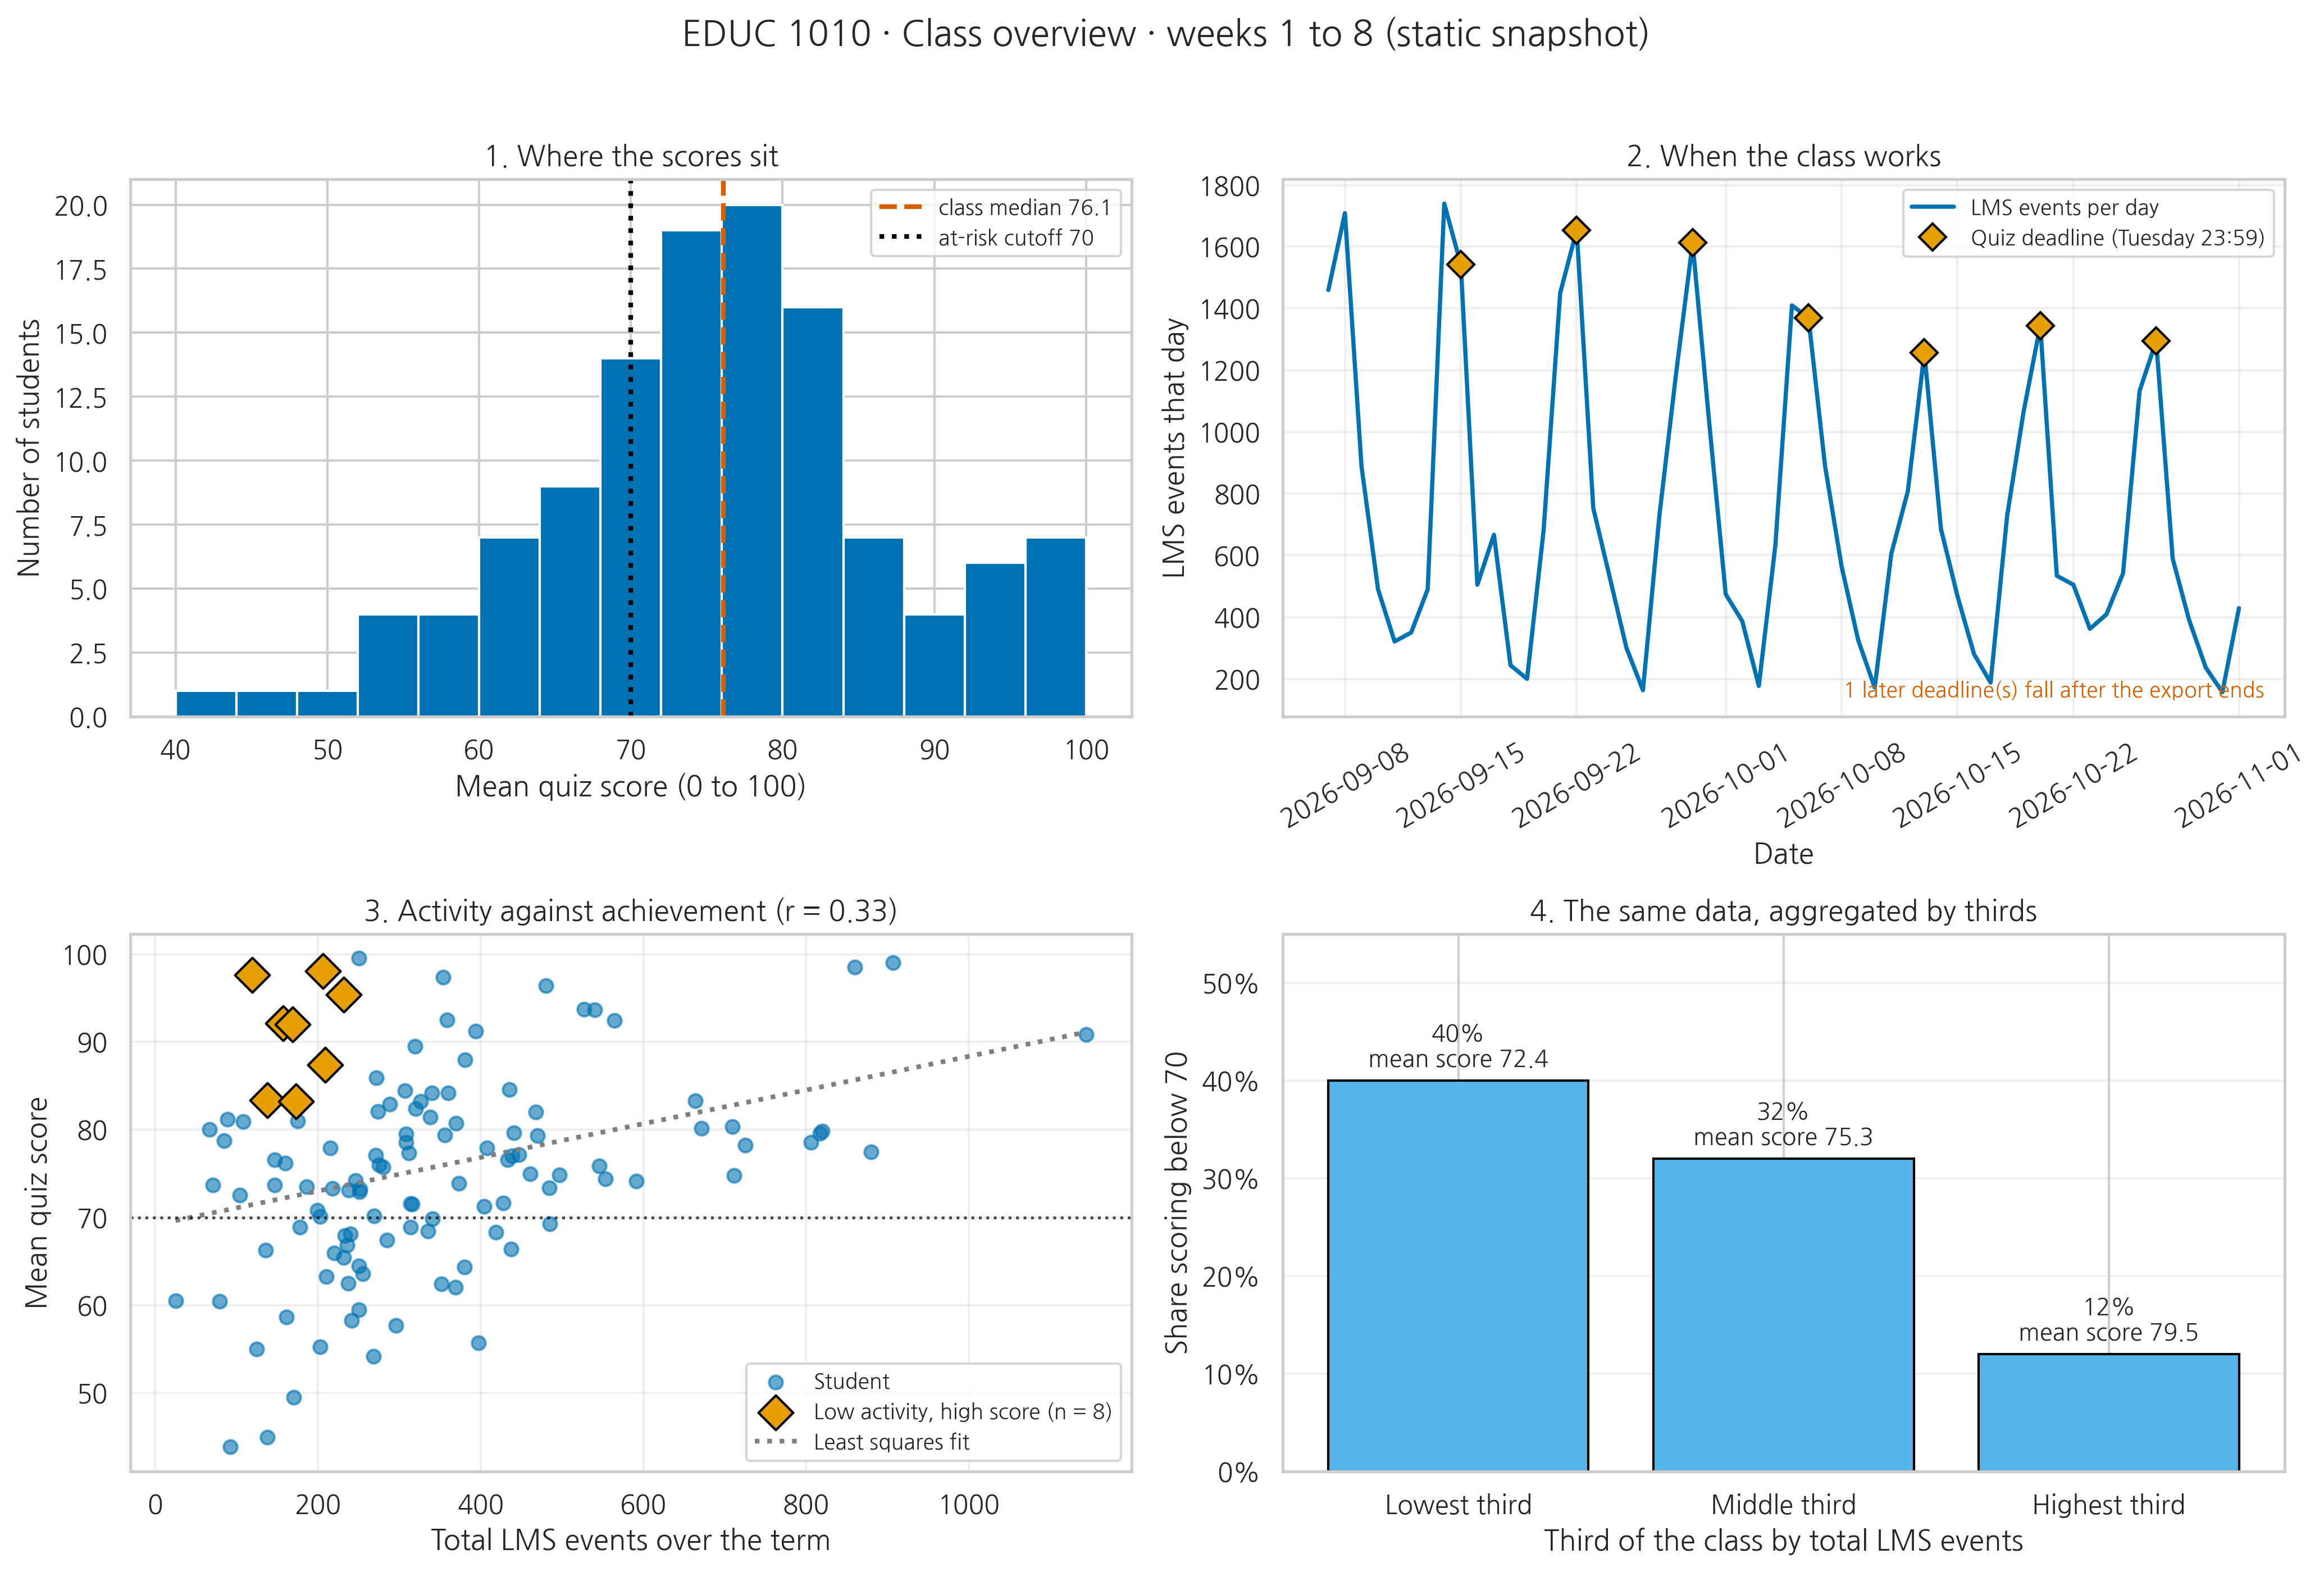

PANEL 4 AS A TABLE
                students  median events  mean quiz score  share below 70
activity_third                                                          
Lowest third          40          169.5            72.43            0.40
Middle third          40          307.5            75.31            0.32
Highest third         40          484.5            79.46            0.12

Correlation between total LMS events and mean quiz score: r = 0.33
That is an r-squared of 0.11: activity volume accounts for about 11% of the
variation in scores, and something else accounts for the other 89%.

Students in the bottom third of activity AND the top quarter of scores: 8
student_id first_name  last_name  total_events  mean_quiz  prior_gpa
      S006     Fatima     Solano           157    92.1375       3.63
      S009   Delphine      Grant           232    95.3500       3.73
      S016       Zara        Kim           138    83.3250       3.49
      S025    Youssef     Achebe           209    87.

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9.5))

# --- 1. distribution -------------------------------------------------------
ax = axes[0, 0]
ax.hist(dash["mean_quiz"], bins=np.arange(40, 104, 4), color=BLUE, edgecolor="white")
ax.axvline(dash["mean_quiz"].median(), color=VERM, linestyle="--", linewidth=2,
           label=f"class median {dash['mean_quiz'].median():.1f}")
ax.axvline(RISK_CUTOFF, color="black", linestyle=":", linewidth=2,
           label=f"at-risk cutoff {RISK_CUTOFF}")
ax.set_title("1. Where the scores sit", fontsize=12)
ax.set_xlabel("Mean quiz score (0 to 100)")
ax.set_ylabel("Number of students")
ax.legend(fontsize=9)

# --- 2. rhythm -------------------------------------------------------------
ax = axes[0, 1]
ax.plot(daily_events.index, daily_events.values, color=BLUE, linewidth=1.8,
        label="LMS events per day")
ax.plot(events_on_deadline_days.index, events_on_deadline_days.values, "D",
        color=ORANGE, markersize=8, markeredgecolor="black", linestyle="none",
        label="Quiz deadline (Tuesday 23:59)")
ax.set_title("2. When the class works", fontsize=12)
ax.set_xlabel("Date")
ax.set_ylabel("LMS events that day")
ax.tick_params(axis="x", rotation=30)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.text(0.98, 0.03, outside_note, transform=ax.transAxes, ha="right", va="bottom",
        fontsize=9, color=VERM)

# --- 3. activity vs achievement -------------------------------------------
ax = axes[1, 0]
ax.scatter(usual["total_events"], usual["mean_quiz"], s=34, color=BLUE, alpha=0.6,
           label="Student")
ax.scatter(eff["total_events"], eff["mean_quiz"], s=110, color=ORANGE, marker="D",
           edgecolor="black", zorder=3,
           label=f"Low activity, high score (n = {len(eff)})")
ax.plot(fit_x, fit_y, color=GREY, linestyle=":", linewidth=2, label="Least squares fit")
ax.axhline(RISK_CUTOFF, color="black", linestyle=":", linewidth=1.2, alpha=0.7)
ax.set_title(f"3. Activity against achievement (r = {r_activity_score:.2f})", fontsize=12)
ax.set_xlabel("Total LMS events over the term")
ax.set_ylabel("Mean quiz score")
ax.legend(fontsize=9, loc="lower right")
ax.grid(alpha=0.3)

# --- 4. the same data, aggregated -----------------------------------------
ax = axes[1, 1]
bars = ax.bar(list(tercile.index), tercile["share_below_cutoff"], color=SKY,
              edgecolor="black")
for b, p, v in zip(bars, tercile["share_below_cutoff"], tercile["mean_score"]):
    ax.text(b.get_x() + b.get_width() / 2, p + 0.015,
            f"{p:.0%}\nmean score {v:.1f}", ha="center", fontsize=10)
ax.set_ylim(0, 0.55)
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("4. The same data, aggregated by thirds", fontsize=12)
ax.set_xlabel("Third of the class by total LMS events")
ax.set_ylabel(f"Share scoring below {RISK_CUTOFF}")
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

fig.suptitle("EDUC 1010 · Class overview · weeks 1 to 8 (static snapshot)", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("PANEL 4 AS A TABLE")
print(tercile.rename(columns={
    "students": "students", "median_events": "median events",
    "mean_score": "mean quiz score", "share_below_cutoff": f"share below {RISK_CUTOFF}",
}).to_string())
print(f"\nCorrelation between total LMS events and mean quiz score: r = {r_activity_score:.2f}")
print(f"That is an r-squared of {r_activity_score**2:.2f}: activity volume accounts for about "
      f"{r_activity_score**2:.0%} of the")
print("variation in scores, and something else accounts for the other "
      f"{1 - r_activity_score**2:.0%}.")
print(f"\nStudents in the bottom third of activity AND the top quarter of scores: {len(eff)}")
print(eff[["student_id", "first_name", "last_name", "total_events", "mean_quiz",
           "prior_gpa"]].to_string(index=False))

**Read the four panels before you read this paragraph, then answer out loud.**

1. Panel 3 and panel 4 are built from the same 120 students. Panel 3 is a cloud with a correlation of 0.33, which is a real relationship explaining about a tenth of the variation in scores. Panel 4 is three bars descending cleanly from 40 percent to 12 percent. Which one would make a teacher more confident, and is that confidence earned by anything other than the choice to aggregate?
2. The orange diamonds in panel 3 are students whose click counts are in the bottom third and whose scores are in the top quarter. If this dashboard nudges a teacher to email the least active students, what does that email say to those particular people?
3. Panel 2 shows Monday and Tuesday spikes against near-silence on Saturday. Name one thing a teacher could reasonably change because of that shape, and one interpretation of it that would be a mistake.
4. Which of these four charts would you cut if you had room for only three? Cutting is a design decision with a defence, and you will need one in the memo.

## 📊 Part C. The early warning panel

This is the panel with teeth. The class overview describes; this one names people.

You built the model underneath it in week 3, and you already audited it. Recall what happened: a logistic regression on activity features reached about 74 percent accuracy and flagged the 30 students who are first generation and work 15 or more hours a week at a false positive rate near 0.24, against about 0.03 for everybody else. Those students work in concentrated bursts, so their count of active days collapsed while their grades stayed ordinary. Swapping the feature set for `prior_gpa`, `total_events`, and `submit` raised accuracy and closed most of the gap.

So the model going on the screen this week is the audited one. That decision is already made. Two design decisions are not:

- **How many names appear.** A teacher cannot have a meaningful conversation with 34 students in a week. We show the 15 highest risk scores, which is a caseload, not a diagnosis. The number is a resourcing decision wearing a statistical costume.
- **Whether the panel explains itself.** A flag with no reason attached is an accusation. We decompose each student's risk score into what each feature contributed, so the panel can say *why* a name is on the list.

The reason works like this. A logistic regression turns standardised features into log-odds by multiplying each one by a coefficient. A student who is one standard deviation below the class mean on `prior_gpa`, where the coefficient is negative, gets a positive push toward "at risk." Adding those pushes across features gives the score, so the largest positive push is a defensible answer to "why is this student here."

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold

y_true = dash["at_risk"].to_numpy()

AUDITED_FEATURES  = ["prior_gpa", "total_events", "submit"]        # the week 3 redesign
ACTIVITY_FEATURES = ["total_events", "active_days", "video_play", "forum_view"]  # retired
CASELOAD = 15     # how many names the teacher can actually act on in one week

FEATURE_LABEL = {"prior_gpa": "Prior GPA",
                 "total_events": "LMS activity volume",
                 "submit": "Submission events",
                 "active_days": "Active days",
                 "video_play": "Video plays",
                 "forum_view": "Forum views"}

def risk_scores(feature_names, seed=8100):
    # Out-of-sample risk score per student: everyone is scored by a model trained
    # on the other four folds, so nobody is scored by a model that saw their outcome.
    X = dash[list(feature_names)].to_numpy(dtype=float)
    pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    return cross_val_predict(pipe, X, y_true, cv=folds, method="predict_proba")[:, 1]

def flag_top_k(scores, k):
    # The caseload rule: flag the k highest scores.
    return (scores >= np.sort(scores)[-k]).astype(int)

scores_audited = risk_scores(AUDITED_FEATURES)
flags_audited  = flag_top_k(scores_audited, CASELOAD)
scores_retired = risk_scores(ACTIVITY_FEATURES)
flags_retired  = flag_top_k(scores_retired, CASELOAD)

# ---- the fairness check, carried forward from week 3 -----------------------
burst_group = ((dash["first_gen"] == 1) & (dash["work_hours_per_week"] >= 15)).to_numpy()

def fpr(flags, mask):
    healthy = mask & (y_true == 0)      # in this group, NOT below the cutoff
    return float(flags[healthy].mean())

def fpr_gap(flags):
    return fpr(flags, burst_group) - fpr(flags, ~burst_group)

# ---- per-student reasons ---------------------------------------------------
X_full = dash[AUDITED_FEATURES].to_numpy(dtype=float)
explain_pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(X_full, y_true)
scaler = explain_pipe.named_steps["standardscaler"]
logreg = explain_pipe.named_steps["logisticregression"]
coefs = logreg.coef_[0]

# contribution of each feature to each student's log-odds
contrib = pd.DataFrame(scaler.transform(X_full) * coefs,
                       columns=AUDITED_FEATURES, index=dash["student_id"])

pct_rank = {f: dash[f].rank(pct=True) for f in AUDITED_FEATURES}

def reason_sentence(i, feature):
    value = dash.loc[i, feature]
    p = pct_rank[feature].iloc[i]
    where = f"bottom {p * 100:.0f}%" if p <= 0.5 else f"top {(1 - p) * 100:.0f}%"
    shown = f"{value:.2f}" if feature == "prior_gpa" else f"{int(value):,}"
    return f"{FEATURE_LABEL[feature]} {shown} ({where} of the class)"

flagged = dash.loc[flags_audited == 1].copy()
flagged["risk_score"] = scores_audited[flags_audited == 1]
lead_feature = contrib.loc[flagged["student_id"]].idxmax(axis=1).to_numpy()
flagged["leading_reason"] = [reason_sentence(i, f) for i, f in zip(flagged.index, lead_feature)]
flagged["lead_feature"] = lead_feature
flagged = flagged.sort_values("risk_score", ascending=False).reset_index(drop=True)
flagged["student"] = flagged["first_name"] + " " + flagged["last_name"]

print("=" * 92)
print("  MODEL CARD: the early warning panel explains itself before it names anybody")
print("=" * 92)
print(f"  Features in use ............ {', '.join(AUDITED_FEATURES)}")
print(f"  Algorithm .................. logistic regression, 5-fold cross validated scores")
print(f"  Flag rule .................. the {CASELOAD} highest risk scores (one week of outreach)")
print(f"  Label being predicted ...... mean quiz score below {RISK_CUTOFF}")
print(f"  Accuracy ................... {(flags_audited == y_true).mean():.3f}"
      f"   (flag nobody at all: {(y_true == 0).mean():.3f})")
print(f"  False positive rate gap .... {fpr_gap(flags_audited):+.3f}"
      "   first generation working 15+ hrs, minus everyone else")
print(f"  Same gap, retired model .... {fpr_gap(flags_retired):+.3f}"
      f"   (features: {', '.join(ACTIVITY_FEATURES)})")
print("  Coefficients (log-odds per standard deviation):")
for f, c in zip(AUDITED_FEATURES, coefs):
    direction = "raises risk" if c > 0 else "lowers risk"
    print(f"      {FEATURE_LABEL[f]:<22} {c:+.2f}   (a higher value {direction})")
print("=" * 92)

print(f"\nSTUDENTS FLAGGED THIS WEEK ({CASELOAD} of {len(dash)})\n")
print(flagged[["student_id", "student", "risk_score", "leading_reason"]]
      .assign(risk_score=lambda d: d["risk_score"].round(2))
      .to_string(index=False))

  MODEL CARD: the early warning panel explains itself before it names anybody
  Features in use ............ prior_gpa, total_events, submit
  Algorithm .................. logistic regression, 5-fold cross validated scores
  Flag rule .................. the 15 highest risk scores (one week of outreach)
  Label being predicted ...... mean quiz score below 70
  Accuracy ................... 0.808   (flag nobody at all: 0.717)
  False positive rate gap .... +0.032   first generation working 15+ hrs, minus everyone else
  Same gap, retired model .... +0.160   (features: total_events, active_days, video_play, forum_view)
  Coefficients (log-odds per standard deviation):
      Prior GPA              -1.64   (a higher value lowers risk)
      LMS activity volume    -1.17   (a higher value lowers risk)
      Submission events      +0.18   (a higher value raises risk)

STUDENTS FLAGGED THIS WEEK (15 of 120)

student_id             student  risk_score                                  leading_reas

Now draw it. The panel has two halves that have to be read together.

On the left, the risk score for each flagged student, longest bar at the top. On the right, the same students with their risk broken into the three feature contributions, in log-odds. A bar pointing right is a push toward being flagged, a bar pointing left is a pull away from it, and the length is how hard the push was.

The right half is the part most real early warning systems do not show, and it is the part that makes the panel arguable rather than authoritative. Look at the shape of it once it appears.

In [7]:
n_flag = len(flagged)
row_labels = [f"{s}  ({sid})" for s, sid in zip(flagged["student"], flagged["student_id"])]
y_pos = list(range(n_flag))[::-1]          # highest risk at the top
contrib_flagged = contrib.loc[flagged["student_id"]]
bar_colors = {"prior_gpa": BLUE, "total_events": ORANGE, "submit": PURPLE}

fig = make_subplots(
    rows=1, cols=2, shared_yaxes=True, horizontal_spacing=0.04,
    column_widths=[0.42, 0.58],
    subplot_titles=("Risk score (0 to 1)", "Why: contribution of each feature (log-odds)"),
)

fig.add_trace(go.Bar(
    x=flagged["risk_score"], y=y_pos, orientation="h", marker_color=BLUE,
    text=[f"{v:.2f}" for v in flagged["risk_score"]], textposition="outside",
    name="Risk score", showlegend=False,
    customdata=flagged["leading_reason"],
    hovertemplate="risk %{x:.2f}<br>%{customdata}<extra></extra>"),
    row=1, col=1)

for feature in AUDITED_FEATURES:
    values = contrib_flagged[feature].to_numpy()
    raw = dash.set_index("student_id").loc[flagged["student_id"], feature].to_numpy()
    fig.add_trace(go.Bar(
        x=values, y=y_pos, orientation="h", name=FEATURE_LABEL[feature],
        marker_color=bar_colors[feature], customdata=raw,
        hovertemplate=(FEATURE_LABEL[feature] + " = %{customdata:.2f}"
                       "<br>contribution %{x:+.2f}<extra></extra>")),
        row=1, col=2)

fig.update_layout(barmode="relative", height=560, width=1080, template="simple_white",
                  title=dict(text=f"EDUC 1010 · Early warning · {n_flag} students flagged "
                                  f"for outreach this week", x=0.5, font=dict(size=18)),
                  legend=dict(orientation="h", yanchor="bottom", y=-0.19,
                              xanchor="center", x=0.5),
                  margin=dict(l=200, r=40, t=90, b=90))
fig.update_yaxes(tickmode="array", tickvals=y_pos, ticktext=row_labels,
                 row=1, col=1, tickfont=dict(size=11))
fig.update_xaxes(title_text="Predicted probability of falling below the cutoff",
                 range=[0, 1.12], row=1, col=1)
fig.update_xaxes(title_text="Push toward (right) or away from (left) being flagged",
                 row=1, col=2)
fig.add_vline(x=0, line_color="black", line_width=1, row=1, col=2)
fig.show()

The static version follows, for readers on GitHub and for anyone printing this. It also prints the tally of leading reasons across the flagged list, which is worth looking at closely.

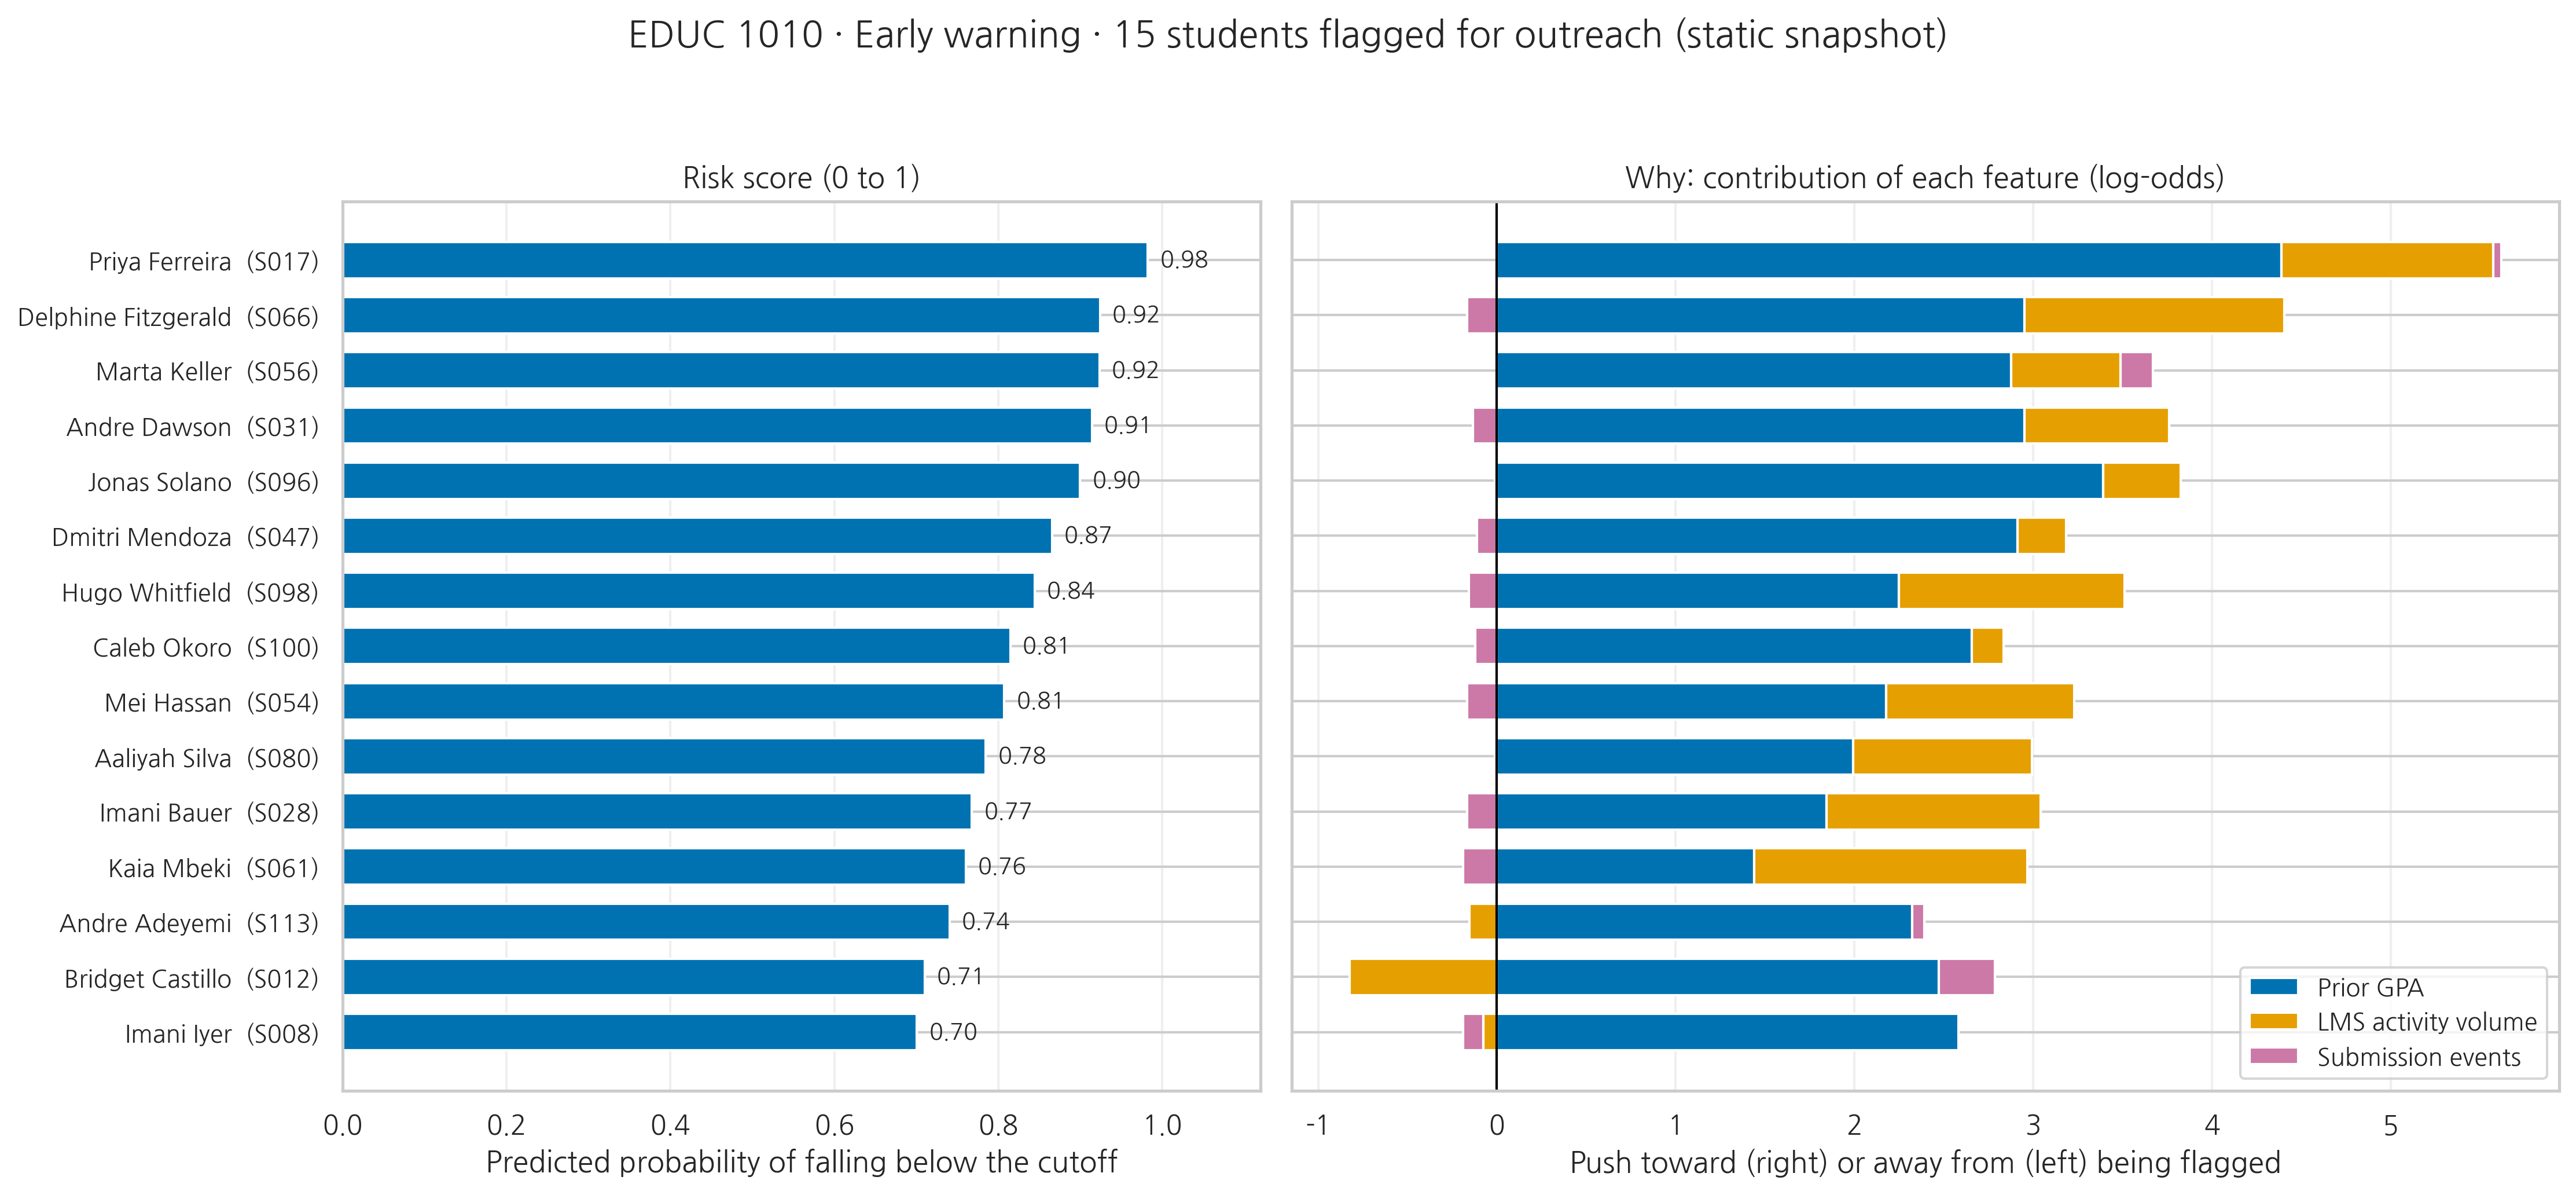

LEADING REASON, TALLIED ACROSS THE FLAGGED LIST
  Prior GPA               14 of 15
  LMS activity volume      1 of 15

Mean prior GPA of the flagged students ....... 2.48
Mean prior GPA of everyone else .............. 3.29


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=True,
                         gridspec_kw={"width_ratios": [0.42, 0.58]})
ypos = np.arange(n_flag)

# --- left: risk score ------------------------------------------------------
ax = axes[0]
ax.barh(ypos, flagged["risk_score"], color=BLUE, height=0.66)
for i, v in enumerate(flagged["risk_score"]):
    ax.text(v + 0.015, i, f"{v:.2f}", va="center", fontsize=9.5)
ax.set_yticks(ypos)
ax.set_yticklabels(row_labels, fontsize=10)
ax.invert_yaxis()
ax.set_xlim(0, 1.12)
ax.set_title("Risk score (0 to 1)", fontsize=12)
ax.set_xlabel("Predicted probability of falling below the cutoff")
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)

# --- right: signed, stacked contributions ---------------------------------
ax = axes[1]
pos = np.zeros(n_flag)
neg = np.zeros(n_flag)
for feature in AUDITED_FEATURES:
    v = contrib_flagged[feature].to_numpy()
    left = np.where(v >= 0, pos, neg)
    ax.barh(ypos, v, left=left, height=0.66, color=bar_colors[feature],
            edgecolor="white", label=FEATURE_LABEL[feature])
    pos = pos + np.clip(v, 0, None)
    neg = neg + np.clip(v, None, 0)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Why: contribution of each feature (log-odds)", fontsize=12)
ax.set_xlabel("Push toward (right) or away from (left) being flagged")
ax.legend(fontsize=10, loc="lower right")
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)

fig.suptitle(f"EDUC 1010 · Early warning · {n_flag} students flagged for outreach "
             "(static snapshot)", fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

tally = flagged["lead_feature"].map(FEATURE_LABEL).value_counts()
print("LEADING REASON, TALLIED ACROSS THE FLAGGED LIST")
for name, n in tally.items():
    print(f"  {name:<22} {n:>3} of {n_flag}")
print("\nMean prior GPA of the flagged students ....... "
      f"{flagged['prior_gpa'].mean():.2f}")
print("Mean prior GPA of everyone else .............. "
      f"{dash.loc[flags_audited == 0, 'prior_gpa'].mean():.2f}")

**Look at the tally before you move on.**

1. One feature supplies the leading reason for almost every name on the list. Say what that means for the teacher who reads the "why" column fifteen times on a Monday morning. What have they learned about their teaching this week?
2. Prior GPA was earned before this course started. Nothing a teacher does between now and December changes it. Is a reason a teacher cannot act on a useful reason, or is it an alibi?
3. Look at the coefficient printed for `Submission events`. It is positive, which means the model treats *more* submission activity as slightly *more* risk, holding the other two features fixed. That is a real property of this fitted model, not a typo. What would you tell a teacher who noticed it? What does it tell you about reading single coefficients as explanations?
4. Week 3 asked whether the model is fair. This panel asks something different: whether it is *useful*. A model can be both fair and useless. Which of those two failures does a teacher notice faster?

### ✏️ Your turn 2: the caseload is the design decision

`CASELOAD = 15` was a guess about how many students a teacher can reach in a week. Change it and watch what moves: how many struggling students the panel finally catches, how many thriving students get an unnecessary email, and whether the fairness gap you closed in week 3 stays closed.

The cell below runs with a working default. Try 8, then 30, then 34 (the number of students actually below the cutoff). Nothing later in the notebook depends on what you choose here.

In [9]:
# ✏️ TODO: change this number and re-run the cell. Try 8, 25, 30, 34.
your_caseload = 25


your_caseload = int(np.clip(your_caseload, 1, len(dash)))     # keep it in range
your_flags = flag_top_k(scores_audited, your_caseload)

overlap = int((your_flags & flags_audited).sum())
caught = int(((your_flags == 1) & (y_true == 1)).sum())
missed = int(((your_flags == 0) & (y_true == 1)).sum())
false_alarms = int(((your_flags == 1) & (y_true == 0)).sum())

print(f"Caseload of {your_caseload} compared with the panel's {CASELOAD}\n")
print(f"  names kept from the original list ........... {overlap} of {CASELOAD}")
print(f"  students below the cutoff who are caught .... {caught} of {int(y_true.sum())}")
print(f"  students below the cutoff who are missed .... {missed}")
print(f"  students doing fine who get contacted ....... {false_alarms}")
print(f"  false positive rate gap (week 3 metric) ..... {fpr_gap(your_flags):+.3f}")
if your_caseload >= CASELOAD:
    print("\n  The lists are nested: raising the caseload only ever adds names to the")
    print("  bottom of the same ranking, so reach goes up and so do the false alarms.")
else:
    print("\n  Shrinking the caseload cuts from the bottom of the ranking, which is")
    print("  exactly where the model is least sure of itself.")
print("\n  Reminder: every one of those four numbers is set by a staffing budget,")
print("  and none of them is set by the model.")

Caseload of 25 compared with the panel's 15

  names kept from the original list ........... 15 of 15
  students below the cutoff who are caught .... 21 of 34
  students below the cutoff who are missed .... 13
  students doing fine who get contacted ....... 4
  false positive rate gap (week 3 metric) ..... +0.001

  The lists are nested: raising the caseload only ever adds names to the
  bottom of the same ranking, so reach goes up and so do the false alarms.

  Reminder: every one of those four numbers is set by a staffing budget,
  and none of them is set by the model.


## 📊 Part D. The individual drilldown

A flag is a claim about a person, and the panel above makes it in a single number. This is where a teacher goes next, and in practice it is the only panel that ever changes anybody's mind.

Four views of one student:

1. **Quiz trajectory**, against the class middle half. Not against the class average, because a single line invites ranking. A shaded band says "here is where most of the class is" without telling this student they are 47th.
2. **Their own profile**, including what the model used and what it did not.
3. **Weekly LMS activity**, against the class median week by week. This is where burst work becomes visible as a pattern rather than as an absence.
4. **How early each quiz was submitted**, in hours before the deadline.

Pick your student in the next cell. The default is `S008`, and there is a reason for that: she is first generation, she works 22 hours a week, she has two weeks with no LMS events at all, and her quiz scores rose across the term. She is exactly the student week 3 was about, and the audited model still put her on the list.

In [10]:
# ✏️ TODO: change the student and re-run this cell and the two below.
#          Some worth looking at, and why:
#            "S008"  first generation, works 22 hrs, two silent weeks, rising scores
#            "S100"  flagged, but his in-course record is steady
#            "S076"  bottom of the class in clicks, top of the class in scores
#            "S061"  low activity and genuinely struggling: the flag is right here
#            "S017"  the highest risk score in the class
STUDENT_ID = "S008"


if STUDENT_ID not in set(dash["student_id"]):
    print(f"No student called {STUDENT_ID}. Falling back to S008.")
    STUDENT_ID = "S008"

row = dash.set_index("student_id").loc[STUDENT_ID]
name = f"{row['first_name']} {row['last_name']}"

# ---- their quizzes against the class middle half --------------------------
quiz_order = [f"quiz_{k}" for k in range(1, 9)]
class_quiz = quizzes.pivot_table(index="student_id", columns="assessment", values="score")[quiz_order]
their_quiz = class_quiz.loc[STUDENT_ID]
q25, q50, q75 = (class_quiz.quantile(q) for q in (0.25, 0.5, 0.75))

# ---- weekly LMS events against the class median ---------------------------
weekly = (clicks.groupby(["student_id", "week"]).size()
          .unstack(fill_value=0).reindex(columns=range(1, 9), fill_value=0))
their_weekly = weekly.loc[STUDENT_ID]
class_weekly_median = weekly.median()

# ---- submission lead time, in hours before the deadline -------------------
quizzes["lead_hours"] = (quizzes["deadline"] - quizzes["submitted_at"]).dt.total_seconds() / 3600
lead = quizzes.pivot_table(index="student_id", columns="assessment", values="lead_hours")[quiz_order]
their_lead = lead.loc[STUDENT_ID]
class_lead_median = lead.median()

# ---- the profile card ------------------------------------------------------
is_flagged = bool(flags_audited[dash["student_id"] == STUDENT_ID][0])
their_risk = float(scores_audited[dash["student_id"] == STUDENT_ID][0])
their_lead_feature = contrib.loc[STUDENT_ID].idxmax()
their_reason = reason_sentence(dash.index[dash["student_id"] == STUDENT_ID][0], their_lead_feature)
score_pct = float((dash["mean_quiz"] < row["mean_quiz"]).mean())

profile = [
    ("Student",              f"{name} ({STUDENT_ID})"),
    ("Major area",           str(row["major_area"])),
    ("Mean quiz score",      f"{row['mean_quiz']:.1f}  (above {score_pct:.0%} of the class)"),
    ("Risk score",           f"{their_risk:.2f}"),
    ("On the flag list",     "yes" if is_flagged else "no"),
    ("Leading reason",       their_reason if is_flagged else "not flagged"),
    ("Prior GPA",            f"{row['prior_gpa']:.2f}   (used by the model)"),
    ("Total LMS events",     f"{int(row['total_events']):,}   (used by the model)"),
    ("Submission events",    f"{int(row['submit'])}   (used by the model)"),
    ("Active days",          f"{int(row['active_days'])} of 56   (NOT used: week 3 retired it)"),
    ("Paid work per week",   f"{int(row['work_hours_per_week'])} hours   (NOT used, and never shown to the model)"),
    ("First generation",     ("yes" if row["first_gen"] == 1 else "no") + "   (NOT used)"),
    ("Multilingual",         ("yes" if row["multilingual"] == 1 else "no") + "   (NOT used)"),
]

print("=" * 78)
print(f"  DRILLDOWN: {name} ({STUDENT_ID})")
print("=" * 78)
for k, v in profile:
    print(f"  {k:<20} {v}")
print("=" * 78)

  DRILLDOWN: Imani Iyer (S008)
  Student              Imani Iyer (S008)
  Major area           nursing
  Mean quiz score      79.4  (above 62% of the class)
  Risk score           0.70
  On the flag list     yes
  Leading reason       Prior GPA 2.49 (bottom 7% of the class)
  Prior GPA            2.49   (used by the model)
  Total LMS events     356   (used by the model)
  Submission events    8   (used by the model)
  Active days          7 of 56   (NOT used: week 3 retired it)
  Paid work per week   22 hours   (NOT used, and never shown to the model)
  First generation     yes   (NOT used)
  Multilingual         no   (NOT used)


Now the four views, side by side. Hover any point in the interactive version to read the exact number.

Notice what the layout is doing. The shaded band and the dashed median line are there so that this student is compared to a *range* rather than to a rank, which is the difference between "you are behind" and "here is where most people are." That is a small choice with a large effect on what the conversation afterwards sounds like.

In [11]:
weeks = list(range(1, 9))
quiz_labels = [f"Q{k}" for k in range(1, 9)]

fig = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "xy"}, {"type": "table"}], [{"type": "xy"}, {"type": "xy"}]],
    subplot_titles=("1. Quiz scores against the class middle half", "2. Profile",
                    "3. LMS events per week", "4. Hours submitted before the deadline"),
    vertical_spacing=0.16, horizontal_spacing=0.09, column_widths=[0.52, 0.48],
)

# panel 1: trajectory inside a band
fig.add_trace(go.Scatter(x=quiz_labels, y=q75.values, mode="lines", line=dict(width=0),
                         showlegend=False, hoverinfo="skip"), row=1, col=1)
fig.add_trace(go.Scatter(x=quiz_labels, y=q25.values, mode="lines", line=dict(width=0),
                         fill="tonexty", fillcolor="rgba(86,180,233,0.30)",
                         name="Middle half of the class", hoverinfo="skip"), row=1, col=1)
fig.add_trace(go.Scatter(x=quiz_labels, y=q50.values, mode="lines",
                         line=dict(color=GREY, dash="dash", width=2), name="Class median",
                         hovertemplate="class median %{y:.1f}<extra></extra>"), row=1, col=1)
fig.add_trace(go.Scatter(x=quiz_labels, y=their_quiz.values, mode="lines+markers",
                         line=dict(color=BLUE, width=3), marker=dict(size=10),
                         name=name, hovertemplate="%{x}: %{y:.1f}<extra></extra>"), row=1, col=1)

# panel 2: profile table
fig.add_trace(go.Table(
    header=dict(values=["<b>Field</b>", "<b>Value</b>"], fill_color="#e8eef4",
                align="left", font=dict(size=12)),
    cells=dict(values=[[k for k, _ in profile], [v for _, v in profile]],
               fill_color=[["white", "#f6f8fa"] * 7], align="left",
               font=dict(size=11), height=24)),
    row=1, col=2)

# panel 3: weekly events
fig.add_trace(go.Bar(x=weeks, y=their_weekly.values, marker_color=BLUE,
                     name=f"{name}: events", showlegend=False,
                     hovertemplate="week %{x}: %{y} events<extra></extra>"), row=2, col=1)
fig.add_trace(go.Scatter(x=weeks, y=class_weekly_median.values, mode="lines+markers",
                         line=dict(color=ORANGE, dash="dash", width=2),
                         marker=dict(symbol="diamond", size=8),
                         name="Class median that week",
                         hovertemplate="class median %{y:.0f}<extra></extra>"), row=2, col=1)

# panel 4: lead time
fig.add_trace(go.Bar(x=quiz_labels, y=their_lead.values, marker_color=PURPLE,
                     name=f"{name}: lead time", showlegend=False,
                     hovertemplate="%{x}: %{y:.0f} hours early<extra></extra>"), row=2, col=2)
fig.add_trace(go.Scatter(x=quiz_labels, y=class_lead_median.values, mode="lines+markers",
                         line=dict(color=ORANGE, dash="dash", width=2),
                         marker=dict(symbol="diamond", size=8),
                         name="Class median lead time", showlegend=False,
                         hovertemplate="class median %{y:.0f} hours<extra></extra>"), row=2, col=2)

fig.update_xaxes(title_text="Quiz", row=1, col=1)
fig.update_yaxes(title_text="Score (0 to 100)", range=[0, 105], row=1, col=1)
fig.update_xaxes(title_text="Course week", tickmode="array", tickvals=weeks, row=2, col=1)
fig.update_yaxes(title_text="LMS events", row=2, col=1)
fig.update_xaxes(title_text="Quiz", row=2, col=2)
fig.update_yaxes(title_text="Hours before deadline", row=2, col=2)

fig.update_layout(height=830, width=1120, template="simple_white",
                  title=dict(text=f"EDUC 1010 · Student drilldown · {name} ({STUDENT_ID})",
                             x=0.5, font=dict(size=19)),
                  legend=dict(orientation="h", yanchor="bottom", y=-0.11,
                              xanchor="center", x=0.5))
fig.show()

And the static snapshot of the same drilldown, so the committed notebook shows this student to a reader on GitHub.

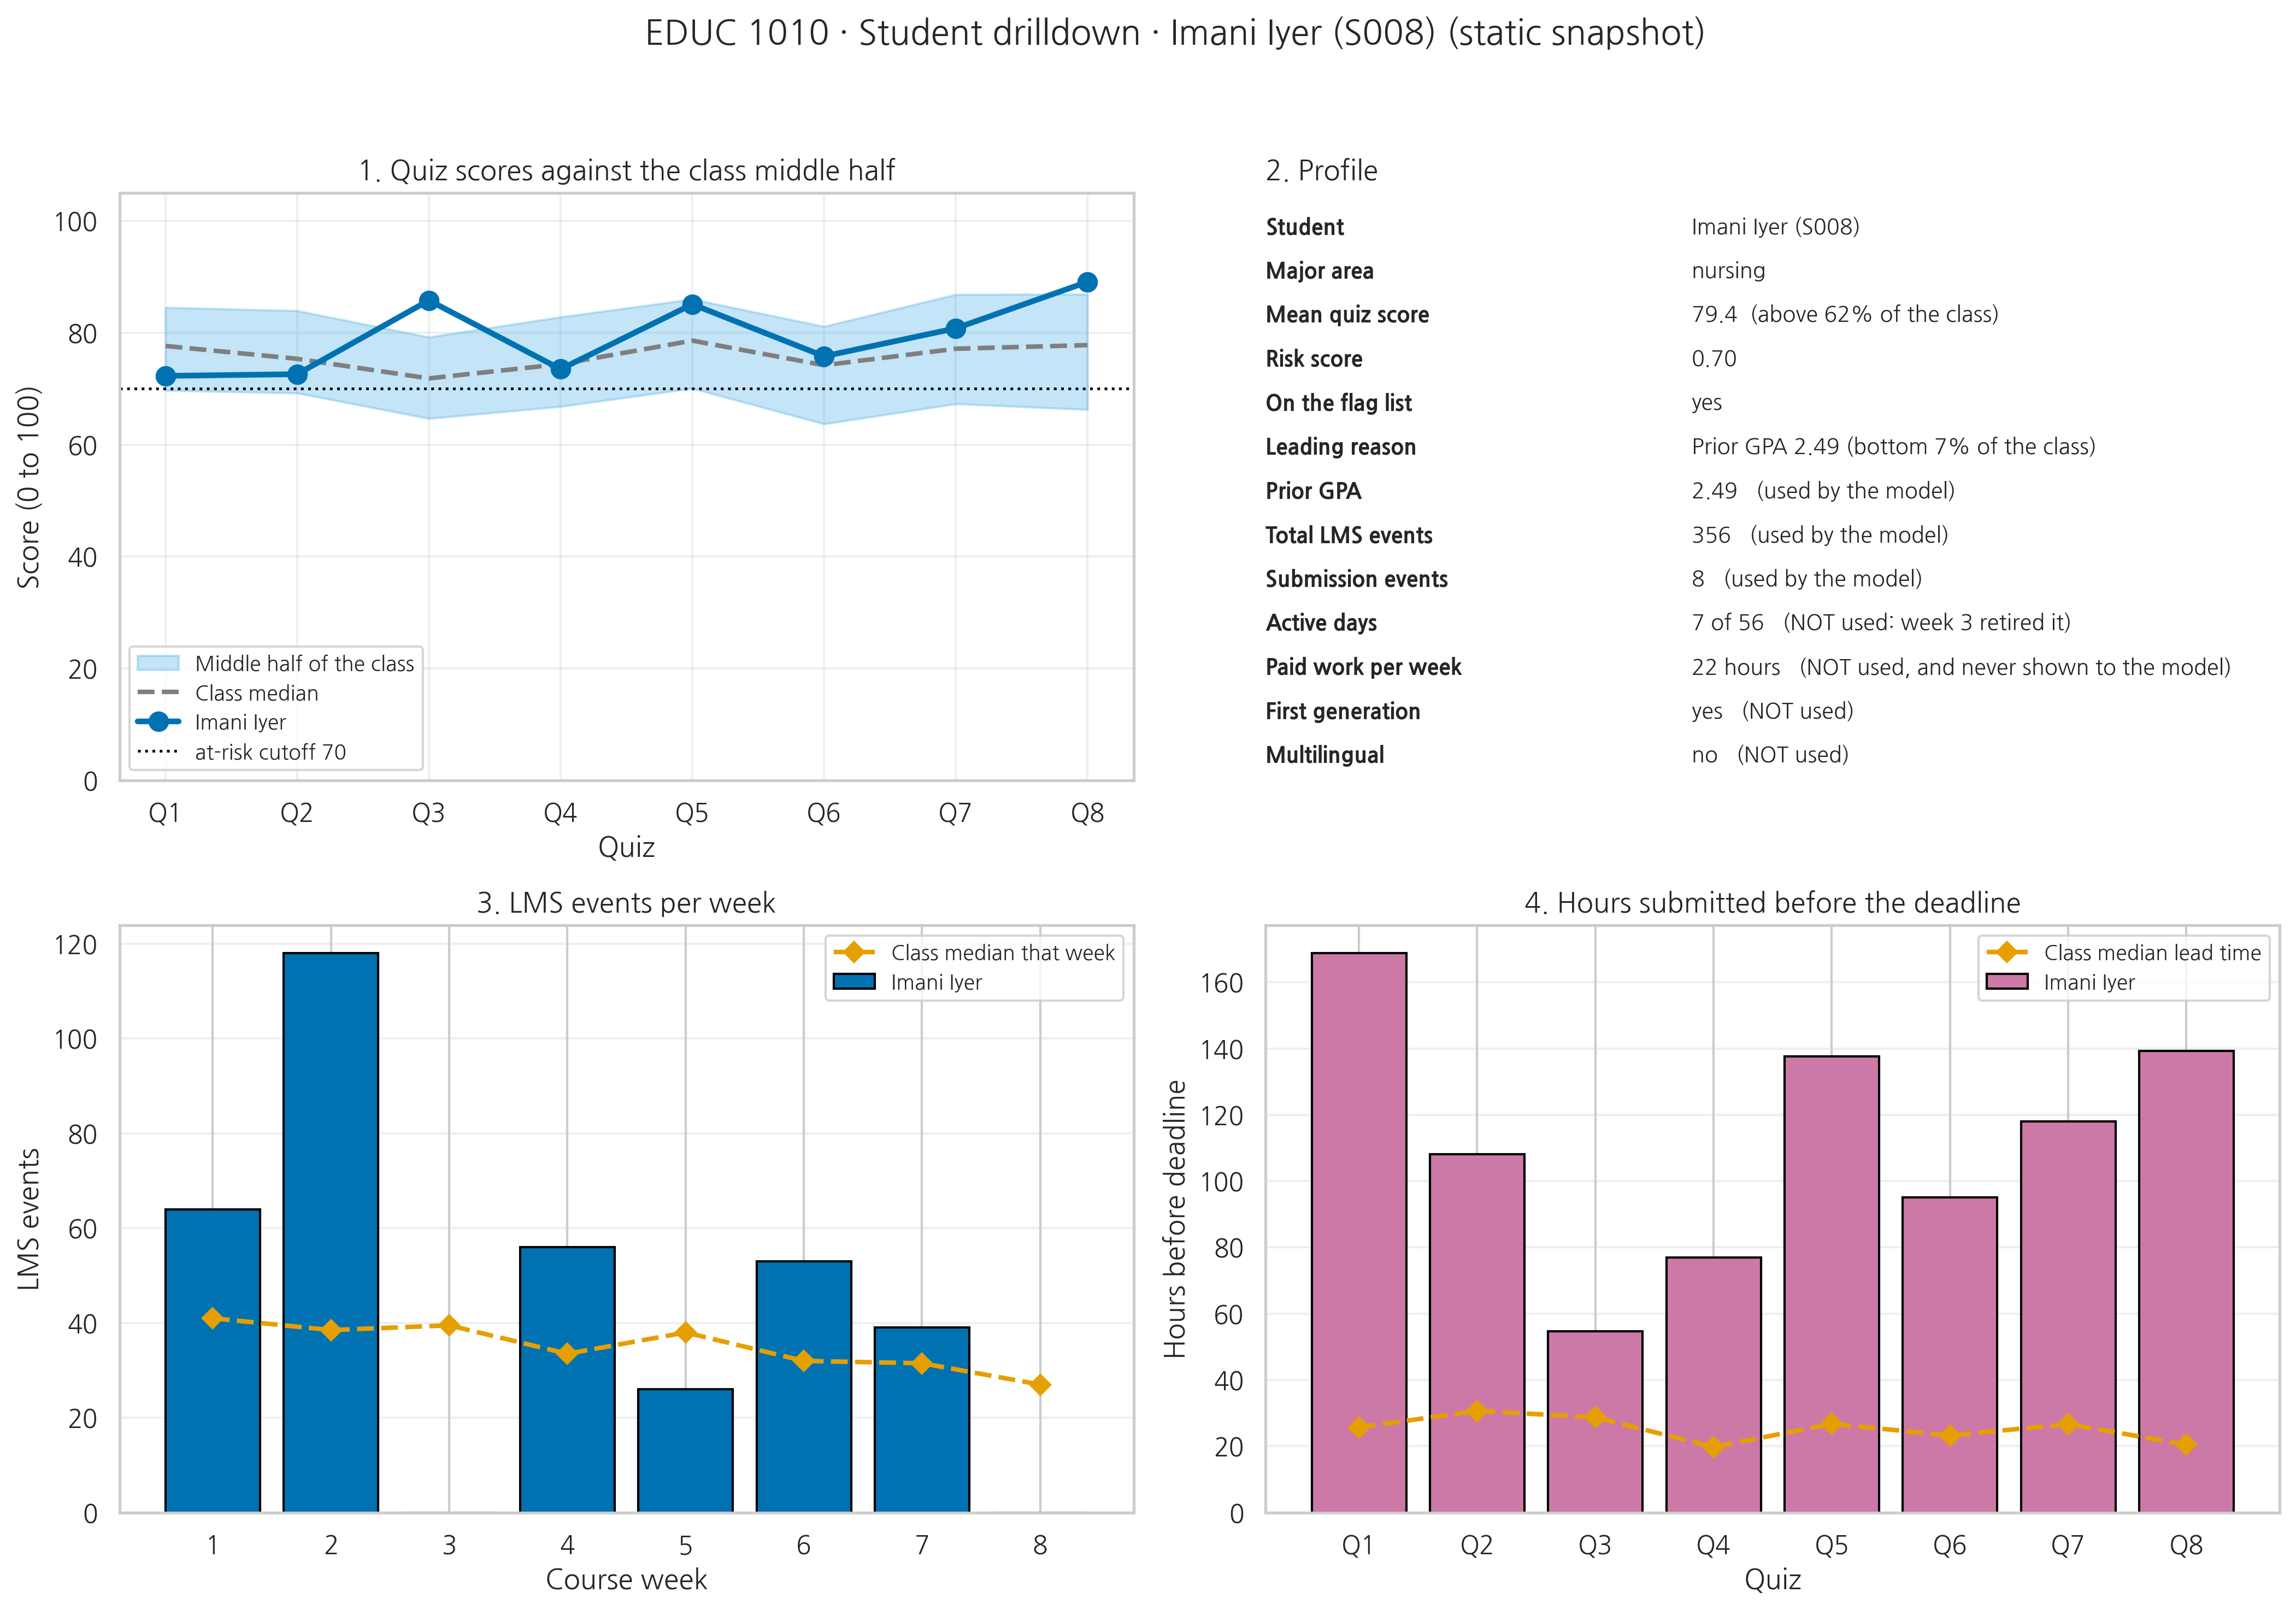

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14.5, 10))

# --- 1. quiz trajectory ----------------------------------------------------
ax = axes[0, 0]
ax.fill_between(quiz_labels, q25.values, q75.values, color=SKY, alpha=0.35,
                label="Middle half of the class")
ax.plot(quiz_labels, q50.values, color=GREY, linestyle="--", linewidth=2,
        label="Class median")
ax.plot(quiz_labels, their_quiz.values, color=BLUE, marker="o", markersize=8,
        linewidth=2.5, label=name)
ax.axhline(RISK_CUTOFF, color="black", linestyle=":", linewidth=1.2,
           label=f"at-risk cutoff {RISK_CUTOFF}")
ax.set_ylim(0, 105)
ax.set_title("1. Quiz scores against the class middle half", fontsize=12)
ax.set_xlabel("Quiz")
ax.set_ylabel("Score (0 to 100)")
ax.legend(fontsize=9, loc="lower left")
ax.grid(alpha=0.3)

# --- 2. profile as text ----------------------------------------------------
ax = axes[0, 1]
ax.axis("off")
ax.set_title("2. Profile", fontsize=12, loc="left")
for j, (k, v) in enumerate(profile):
    ax.text(0.0, 0.96 - j * 0.075, f"{k}", fontsize=9.5, fontweight="bold",
            va="top", transform=ax.transAxes)
    ax.text(0.42, 0.96 - j * 0.075, f"{v}", fontsize=9.5, va="top",
            transform=ax.transAxes)

# --- 3. weekly events ------------------------------------------------------
ax = axes[1, 0]
ax.bar(weeks, their_weekly.values, color=BLUE, edgecolor="black", label=f"{name}")
ax.plot(weeks, class_weekly_median.values, color=ORANGE, marker="D", linestyle="--",
        linewidth=2, label="Class median that week")
ax.set_title("3. LMS events per week", fontsize=12)
ax.set_xlabel("Course week")
ax.set_ylabel("LMS events")
ax.set_xticks(weeks)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

# --- 4. lead time ----------------------------------------------------------
ax = axes[1, 1]
ax.bar(quiz_labels, their_lead.values, color=PURPLE, edgecolor="black", label=f"{name}")
ax.plot(quiz_labels, class_lead_median.values, color=ORANGE, marker="D", linestyle="--",
        linewidth=2, label="Class median lead time")
ax.set_title("4. Hours submitted before the deadline", fontsize=12)
ax.set_xlabel("Quiz")
ax.set_ylabel("Hours before deadline")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

fig.suptitle(f"EDUC 1010 · Student drilldown · {name} ({STUDENT_ID}) (static snapshot)",
             fontsize=15)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**Answer these about the student you drilled into.**

1. Write the first sentence of the email a teacher sends after looking at the early warning panel alone. Now write it again after looking at this drilldown. If the two sentences are different, the panel above them is doing something to teachers that is worth naming.
2. Panel 3 shows weeks with no activity at all for the default student. Week 3 taught you what those weeks are. What would a teacher who had not taken week 3 conclude from that chart, and what in the design of the panel invited the wrong conclusion?
3. The profile card deliberately lists the attributes the model never saw, including paid work hours and first generation status. Some dashboards hide those; some show them. Make the argument for showing them, then make the argument against, and say which you would ship.
4. Which single view would you hand to the student themselves, unchanged? Which would you never show them? Hold on to your answer, it is the stretch goal.

## 💬 Part E. Take it apart

You have three panels. Now do the harder half of this assignment.

van Leeuwen, Teasley, and Wise (2022) draw the line this whole notebook sits on: teacher-facing and student-facing analytics are not the same tool with different logins. They answer to different decisions, they carry different risks, and a display that is supportive for one can be corrosive for the other. Wise and Jung (2019) push further, and their finding is the uncomfortable one: what an instructor does with a dashboard depends far more on their pedagogical situation, their read of the moment, and the moves they already had available than on what the numbers say. The data does not produce the decision. It enters an interpretation that is already underway.

So the question is not "is this dashboard accurate." It is: **what would a teacher do differently on Monday because of each panel, and where would that action go wrong?**

The next cell computes five things you should have in front of you before you write. None of them are visible on the dashboard itself, and one of them is the reason a teacher would need this notebook and not just the screen.

In [13]:
print("=" * 88)
print("  FIVE THINGS THE DASHBOARD DOES NOT SHOW THE TEACHER")
print("=" * 88)

# --- 1. coverage: who is on the list, and who is not ------------------------
n_at_risk = int(y_true.sum())
true_positives = int(((flags_audited == 1) & (y_true == 1)).sum())
false_positives = int(((flags_audited == 1) & (y_true == 0)).sum())
missed = int(((flags_audited == 0) & (y_true == 1)).sum())

print(f"\n1. COVERAGE. The panel shows {CASELOAD} names.")
print(f"   Students actually below the cutoff .................. {n_at_risk}")
print(f"   Of the {CASELOAD} flagged, actually below the cutoff ......... {true_positives}")
print(f"   Of the {CASELOAD} flagged, actually doing fine ............... {false_positives}")
print(f"   Students below the cutoff who never appear .......... {missed}")
print(f"   A teacher who works the list reaches {true_positives / n_at_risk:.0%} of the students")
print("   who need them, and hears nothing at all about the rest.")

# --- 2. stability: would the same names appear tomorrow? --------------------
appearances = pd.Series(0, index=dash["student_id"])
for seed in [1, 2, 3, 4, 5]:
    appearances[dash.loc[flag_top_k(risk_scores(AUDITED_FEATURES, seed=seed), CASELOAD) == 1,
                         "student_id"]] += 1
ever = appearances[appearances > 0]
always = int((ever == 5).sum())

print(f"\n2. STABILITY. The same model, the same data, five different random splits")
print("   for the cross validation. Nothing about the students changed.")
print(f"   Students who appear on all 5 lists .................. {always}")
print(f"   Students who appear on some lists but not others .... {len(ever) - always}")
print(f"   Distinct students who appeared at least once ........ {len(ever)} for {CASELOAD} slots")
print("   The bottom of the list is a coin flip, and the screen shows no difference")
print("   between a name at the top and a name at the bottom.")

# --- 3. what the reason column really says ---------------------------------
share_gpa = float((flagged["lead_feature"] == "prior_gpa").mean())
print(f"\n3. THE REASON COLUMN. {share_gpa:.0%} of the flags lead with prior GPA,")
print("   a number fixed before the first day of class. The panel's explanation is")
print("   real, and it is also an explanation no teaching move can act on.")

# --- 4. what the class overview would cost --------------------------------
low_third = dash["activity_third"] == "Lowest third"
thriving_low = int((low_third & (dash["mean_quiz"] >= dash["mean_quiz"].quantile(0.75))).sum())
struggling_high = int(((dash["activity_third"] == "Highest third") & (y_true == 1)).sum())
print(f"\n4. THE COST OF THE ACTIVITY PANEL. Suppose a teacher emails the least")
print(f"   active third of the class ({int(low_third.sum())} students) after reading panels 3 and 4.")
print(f"   Students in that group scoring in the top quarter of the class ...... {thriving_low}")
print(f"   Students below the cutoff who are in the MOST active third .......... {struggling_high}")
print("   The email reaches people who are thriving and misses people who are not.")

# --- 5. the calendar again -------------------------------------------------
last_week_events = int((clicks["week"] == 8).sum())
print(f"\n5. THE CALENDAR. The clickstream ends {export_end:%d %b}. Quiz 8 is due"
      f" {deadlines['quiz_8']:%d %b}")
print(f"   and the final project {final_deadline:%d %b}. Every activity panel in this")
print("   dashboard goes stale exactly when the stakes are highest, and it will keep")
print("   drawing a confident chart while it does.")
print("\n" + "=" * 88)

  FIVE THINGS THE DASHBOARD DOES NOT SHOW THE TEACHER

1. COVERAGE. The panel shows 15 names.
   Students actually below the cutoff .................. 34
   Of the 15 flagged, actually below the cutoff ......... 13
   Of the 15 flagged, actually doing fine ............... 2
   Students below the cutoff who never appear .......... 21
   A teacher who works the list reaches 38% of the students
   who need them, and hears nothing at all about the rest.

2. STABILITY. The same model, the same data, five different random splits
   for the cross validation. Nothing about the students changed.
   Students who appear on all 5 lists .................. 13
   Students who appear on some lists but not others .... 4
   Distinct students who appeared at least once ........ 17 for 15 slots
   The bottom of the list is a coin flip, and the screen shows no difference
   between a name at the top and a name at the bottom.

3. THE REASON COLUMN. 93% of the flags lead with prior GPA,
   a number fixed bef

### ✏️ Your turn 3: the critique table

Fill this in. It is the analytic core of Mini Project 1, and it is what the memo argues from. Double click this cell to edit it, replace the bracketed text, and keep each entry to one or two sentences.

Two rules that make this hard in a useful way. In the action column, name something a teacher could actually do on a Monday: send a specific message, change a specific activity, reorganise a specific ten minutes of class. "Monitor the student" is not an action. In the misleads column, name a specific person or group who gets the wrong end of it, using evidence from the printouts above.

| Panel | What a teacher would actually do | What could mislead them, and who pays |
|---|---|---|
| **B. Class overview** | [your answer] | [your answer] |
| **C. Early warning** | [your answer] | [your answer] |
| **D. Drilldown** | [your answer] | [your answer] |

Then answer these three, in a sentence or two each, below the table.

**a. Wise and Jung (2019) argue that instructional decisions are situated: the same number leads to different actions depending on where the teacher is in their course, their pedagogy, and their relationship with the class.** Pick one panel and describe two teachers who would read it identically and act on it in opposite ways. What does that imply about what the panel should display next to the number?

*[your answer]*

**b. van Leeuwen, Teasley, and Wise (2022) separate teacher-facing from student-facing analytics.** Take one element of your dashboard and say precisely what would have to change before a student could see it, and what harm the unchanged version would do.

*[your answer]*

**c. The stability printout showed that some names on the flag list are there because of a random seed.** Design one concrete interface change that communicates that uncertainty to a teacher without making the panel unusable. Say what your change costs.

*[your answer]*

## ✅ Part F. The design memo (300 words)

**This is a graded component of Mini Project 1.** Double click this cell and write your memo in place of the prompts below. Aim for 300 words, give or take about thirty. Prose, not bullets: you are making an argument, and an argument needs sentences that commit to something.

Your memo has one job: **argue for one specific change to this dashboard, and defend it against the strongest objection you can think of.**

A memo that earns the top band does four things.

1. **Names the decision.** Which teacher, at what moment in their week, facing what choice. Wise and Jung's situated model is the standard here: a memo that describes a display without describing the decision it enters has not started yet.
2. **Cites its own evidence.** Use the numbers from this notebook, not adjectives. The share of the class the flag list reaches. The share of flags whose leading reason is a number fixed before the course began. The count of students who are quiet and thriving.
3. **Proposes one change, specifically.** Not "add more context." Say what appears on the screen, where, in what form, and what it displaces. Every addition to a dashboard costs attention that something else was using.
4. **Names who is protected and what it costs.** Every design decision here trades somebody's error against somebody else's. Say whose, and say what you are willing to give up.

---

### Design memo

*[Replace this whole block with your memo.]*

**The decision this dashboard enters.** [Which teacher, which moment, which choice they are facing.]

**What the current design does to that decision.** [Cite two specific numbers from this notebook.]

**The change I would make.** [One change. Be concrete about what appears on screen and what it replaces.]

**Who this protects, what it costs, and the best argument against it.** [Name the group. Name the trade. Then take the objection seriously enough to state it in its strongest form.]

*Word count: [fill in]*

## ✏️ Stretch goal: redesign one panel as student facing

For students who finish early, or who arrived with programming experience. This is not required, and it is the most interesting thing in the notebook.

van Leeuwen, Teasley, and Wise (2022) make the case that a student-facing display is a different instrument, not the same one with a different login. Jung and Wise (2025) go further and study what students actually do with analytics they receive: whether they open it at all, whether it turns into action, and what routines it builds or breaks.

The cell below contains a working student-facing rewrite of the drilldown, so you can see one before you build yours. Read what it removed and why, then change it. Some things worth trying: replace the class band with the student's own earlier scores, replace the score axis with a "what to do next" list, remove the number entirely and keep only the trend.

Then write two or three sentences in the reflection below: what changed, what you removed, and what a student can now do that they could not do before.

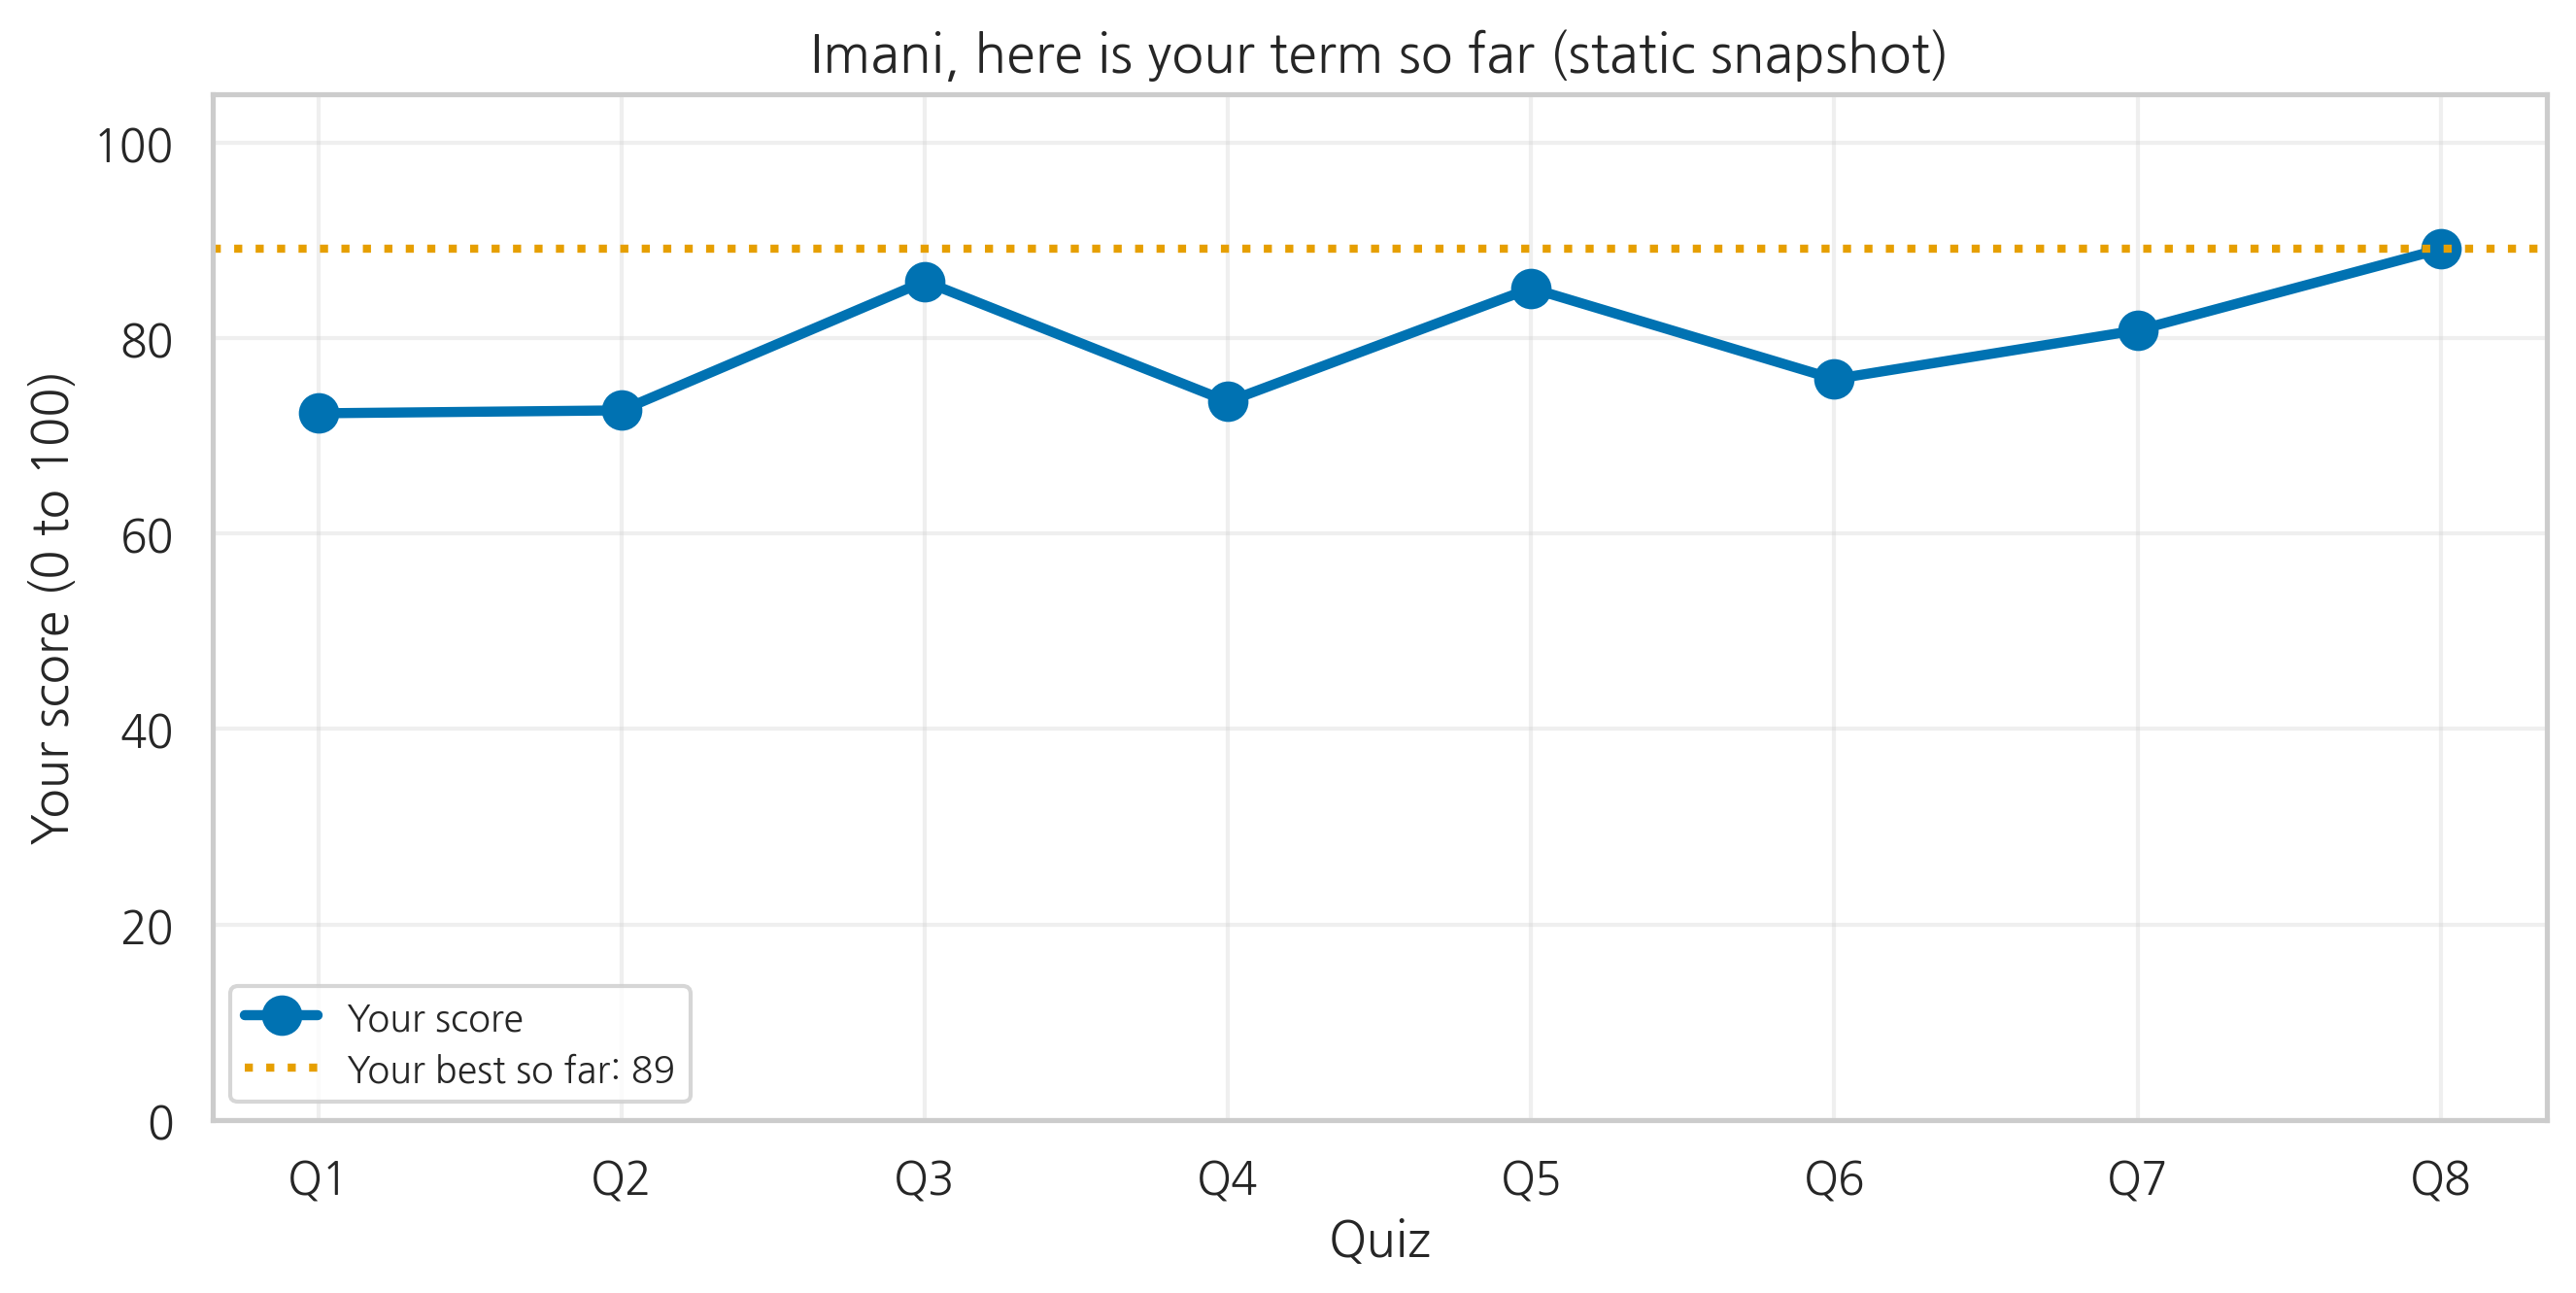

Your last three quizzes averaged 82. Your first three averaged 77. That is up.

WHAT THIS VERSION DELETED, AND WHY
  the risk score ....... a probability about you, computed from your past, that you
                         cannot change and cannot argue with
  the class rank ....... turns a course into a comparison, which is not what the
                         teacher needed the panel for
  prior GPA ............ visible to the model, invisible here: telling a student
                         their history predicts them is not feedback
  the LMS activity ..... clicks are not effort, and the week 3 audit is the reason
                         we know that showing them punishes the wrong people

WHAT IT KEPT: the trend, and the student's own best score as the reference point.


In [14]:
# ✏️ TODO (stretch): this is a working student-facing version of the drilldown.
#      Change it. The comments mark each design decision you could argue with.

SHOW_CLASS_COMPARISON = False   # try True and decide whether it helped or hurt
STUDENT_FACING_ID = STUDENT_ID


sf = dash.set_index("student_id").loc[STUDENT_FACING_ID]
sf_name = sf["first_name"]
sf_quiz = class_quiz.loc[STUDENT_FACING_ID]
sf_best = sf_quiz.max()
sf_recent = sf_quiz.iloc[-3:].mean()
sf_earlier = sf_quiz.iloc[:3].mean()
direction = "up" if sf_recent > sf_earlier else ("steady" if abs(sf_recent - sf_earlier) < 2 else "down")

fig = go.Figure()
if SHOW_CLASS_COMPARISON:
    fig.add_trace(go.Scatter(x=quiz_labels, y=q50.values, mode="lines",
                             line=dict(color=GREY, dash="dash"), name="Class median"))
fig.add_trace(go.Scatter(x=quiz_labels, y=sf_quiz.values, mode="lines+markers",
                         line=dict(color=BLUE, width=3), marker=dict(size=11),
                         name="Your score",
                         hovertemplate="%{x}: %{y:.1f}<extra></extra>"))
fig.add_hline(y=float(sf_best), line_dash="dot", line_color=ORANGE,
              annotation_text=f"your best so far: {sf_best:.0f}",
              annotation_position="top left")
fig.update_layout(
    height=430, width=860, template="simple_white",
    title=dict(text=f"{sf_name}, here is your term so far", x=0.5, font=dict(size=18)),
    xaxis_title="Quiz", yaxis_title="Your score (0 to 100)",
    yaxis=dict(range=[0, 105]))
fig.show()

# --- static snapshot of the student-facing panel ---------------------------
fig, ax = plt.subplots(figsize=(9, 4.6))
if SHOW_CLASS_COMPARISON:
    ax.plot(quiz_labels, q50.values, color=GREY, linestyle="--", linewidth=2,
            label="Class median")
ax.plot(quiz_labels, sf_quiz.values, color=BLUE, marker="o", markersize=9,
        linewidth=2.5, label="Your score")
ax.axhline(sf_best, color=ORANGE, linestyle=":", linewidth=2,
           label=f"Your best so far: {sf_best:.0f}")
ax.set_ylim(0, 105)
ax.set_title(f"{sf_name}, here is your term so far (static snapshot)", fontsize=13)
ax.set_xlabel("Quiz")
ax.set_ylabel("Your score (0 to 100)")
ax.legend(fontsize=9, loc="lower left")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

print(f"Your last three quizzes averaged {sf_recent:.0f}. Your first three averaged "
      f"{sf_earlier:.0f}. That is {direction}.")
print("\nWHAT THIS VERSION DELETED, AND WHY")
print("  the risk score ....... a probability about you, computed from your past, that you")
print("                         cannot change and cannot argue with")
print("  the class rank ....... turns a course into a comparison, which is not what the")
print("                         teacher needed the panel for")
print("  prior GPA ............ visible to the model, invisible here: telling a student")
print("                         their history predicts them is not feedback")
print("  the LMS activity ..... clicks are not effort, and the week 3 audit is the reason")
print("                         we know that showing them punishes the wrong people")
print("\nWHAT IT KEPT: the trend, and the student's own best score as the reference point.")

## 💬 Reflection

Bring your answers to the 5:00 discussion block. Our guest this week is Yeonji Jung of Texas A&M University, whose work is directly about the second and third questions here.

1. **van Leeuwen, Teasley, and Wise (2022)** describe teacher-facing and student-facing analytics as answering different questions for different actors. Having built one and sketched the other, what is the sharpest difference you actually encountered in the design, as opposed to the one you expected?

2. **Wise and Jung (2019)** argue that instructional decision making is situated: the same display leads to different actions depending on the instructor's pedagogy and their reading of the moment. Where in your dashboard did you find yourself designing for a teacher you had imagined? Describe that teacher. What did you assume about them that a colleague might not share?

3. **Jung and Wise (2025)** study how students actually engage with analytics they receive: whether they access it, whether they act, and what routines it forms. Your stretch panel assumed a student who looks. What would you change if you assumed a student who looks once, in week 7, the night before a deadline?

4. **Li, Jung, and Wise (2025)** find that pedagogy is the pivotal factor in how instructors use analytics. If that is right, then the highest-leverage change to this dashboard might not be a change to the dashboard. What is it?

5. And the question that runs underneath the whole week: this dashboard was built on a roster of 120 invented people. Which of the decisions you made this week would you have made differently if the names were real, and what does that difference tell you?

## ✅ Submission checklist: Mini Project 1

Due this week via Canvas. Check every box before you upload.

**The notebook**

- [ ] Runs top to bottom without errors. In Colab: `Runtime > Restart and run all`. Watch it finish.
- [ ] ✏️ Your turn 1 contains your two questions, not the defaults.
- [ ] ✏️ Your turn 2 records a caseload you chose, and you can say why.
- [ ] ✏️ Your turn 3, the critique table in Part E, is filled in for all three panels, plus the three questions underneath it.
- [ ] Part D was run on at least one student you chose yourself, and the outputs for that student are visible in the saved file.
- [ ] Download it: `File > Download > Download .ipynb`. Upload that file to Canvas.

**The design memo**

- [ ] Written in the marked cell in Part F, roughly 300 words.
- [ ] Names a decision, cites at least two numbers from your own outputs, proposes one specific change, and states the strongest objection to it.

**The AI interaction log (course policy, required)**

- [ ] If you used an AI assistant at any point, to explain a line of code, to check your reading of a chart, or to help you draft the memo, save the full exchange.
- [ ] Upload it, plus a short reflection on how you used it and what you checked yourself, to the Canvas **AI Reflection** submission.
- [ ] If you used no AI at all, say so in one line. That is also documentation.

AI use is permitted in designated activities and must be documented. Undisclosed use is an Honor Code violation. The reflection matters more than the log: what did you accept from the assistant, and how did you verify it?

**One last read before you upload.** Open your notebook and look at it the way a colleague would, scrolling once from top to bottom. The static snapshots should tell the story even to somebody who never runs a cell. That is the standard: your reader should be able to see what you saw.

## Appendix: solutions to the ✏️ Your turn cells

These are worked examples, not answer keys. Your version being different is expected and is usually better, because it comes from a course you have actually taught or taken.

### ✏️ Your turn 1: the two questions

```python
QUESTION_THE_FILES_CAN_INFORM = (
    "Which students submitted quiz 6 within two hours of the deadline, and how did "
    "their quiz 6 score compare with their own average?"
)

QUESTION_THE_FILES_CANNOT_TOUCH = (
    "Which students were caring for a family member during weeks 5 and 6, and would "
    "an extension have changed anything for them?"
)
```

The second one is the point. It is answerable, it matters more than anything on the dashboard, and no amount of clickstream will get you there. Every panel you built is silent about it, and silent in a way that looks like completeness.

### ✏️ Your turn 2: the caseload

A worked run at three settings:

```python
your_caseload = 8    # reaches few students, most of them genuinely struggling
your_caseload = 25   # the week 3 setting: more reach, more unnecessary emails
your_caseload = 34   # matches the number actually below the cutoff
```

The thing to notice is that even at 34, the panel does not catch all 34 struggling students. The flags are ranked by a model, not by the outcome, so raising the caseload adds names from the top of the ranking, and some students below the cutoff sit far down that ranking. Raising the caseload buys reach at a falling rate, and every added name is a real conversation somebody has to have.

A defensible answer sounds like: "15, because our advising office has one person for this course and 15 substantive conversations is a week of their time. I would rather reach 40 percent of struggling students well than 90 percent of them with a form email."

### ✏️ Your turn 3: the critique table

One row, worked at the level the rubric expects:

| Panel | What a teacher would actually do | What could mislead them, and who pays |
|---|---|---|
| **C. Early warning** | Send fifteen personal messages on Monday morning offering office hours, and reserve two studio slots for the four students with the lowest quiz 6 scores. | The reason column leads with prior GPA for nearly every name, so the list is close to a ranking of who arrived with the lowest GPA. A teacher working it faithfully spends their outreach week on students the institution already knew about, while the students whose scores dropped *during* this course, and who are the ones a teaching move could still reach, do not appear at all. The people who pay are the newly struggling, who are invisible, and the flagged students with low prior GPA who are doing fine, who get contacted about a number they cannot change. |

For question (c), on communicating instability: one workable answer is to show the risk score as a horizontal band rather than a point, with the band's width taken from the spread across cross validation splits, and to sort the list into "consistently flagged" and "borderline" groups instead of ranking one to fifteen. The cost is honest and real: the panel gets harder to skim, and a teacher in a hurry may read the borderline group as "ignore these." That cost is worth stating in your answer rather than hiding.

### ✏️ Stretch: the student-facing redesign

The version in the notebook keeps the trend and the student's own best score, and deletes the risk score, the class rank, prior GPA, and the activity count. A stronger version goes further and attaches an action to the chart: next to each quiz, one specific thing available now, the practice set, office hours on Thursday, the studio group. The design claim is that a student-facing display without an available action is not feedback, it is a report card that arrived early.

Setting `SHOW_CLASS_COMPARISON = True` is worth doing once. The chart becomes more informative and, for a student in the bottom third, considerably worse. That tension is the assignment.

---

EDIS 8100: Teaching and Learning Analytics · Fall 2026 · Dr. Hakeoung Hannah Lee
University of Virginia School of Education and Human Development